In [1]:
forget()
import statistics
import math
import os
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
from IPython.core.display import display, HTML
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Rectangle  # Add this import statement
# COMENÇA EL PROGRAMA, NO CAL FER RES AQUÍ
global gravedad
global incerteses_sw

incerteses_sw =[]
gravedad = 9.8

class Measure:
    objects = []

    def __init__(self,name, variable_name, mag_inc, unitats):
#         assert (magnitude.parent() == RR) and (incertesa.parent() == RR) and (isinstance(units, str)
        self.name = name

        self.var_name = variable_name
        self.var_inc_name = f"{variable_name}_inc"
        self.var = var(variable_name)
        self.var_inc = var(f"{variable_name}_inc")

#         self.magnitude = mag_inc[0].n()
#         self.incertesa = mag_inc[1].n()


        if isinstance(mag_inc[0], np.float):
            self.magnitude = mag_inc[0]
        else:
            self.magnitude = mag_inc[0].n()
#         print("From measure, magitud e incertesa:",mag_inc[0],mag_inc[1] )
        if isinstance(mag_inc[1], np.float):
            self.incertesa = mag_inc[1]
        else:
            self.incertesa = mag_inc[1].n()

        self.unitats = unitats

        Measure.objects.append(self)


    def __repr__(self):
        if type(self.magnitude) == float:
            return repr(f"{(self.name).capitalize()}: ({self.magnitude} +/- {self.incertesa}) {self.unitats}")            
        else:
            return repr(f"{(self.name).capitalize()}: ({self.magnitude} +/- {self.incertesa}) {self.unitats}")

class Measure_list(Measure):
    def __init__(self,variable_name, name, valors,inc_inst, unitats):
        assert isinstance(valors, list), "fica una llista"
        suma = 0
        val_prom = mean(valors)
        num = len(valors) - 1
        for x in valors:
            suma += (val_prom-x)**2

        stdev = sqrt(suma/num)
        inc_est = stdev/sqrt(num + 1)

        inc = sqrt((inc_est**2) + (inc_inst**2))
        Measure.__init__(self, variable_name, name, [val_prom,inc], unitats)

        self.stdev = stdev
        self.inc_ins = inc_inst

    def __repr__(self):
        return f"{(self.name).capitalize()}: ({self.magnitude} +/- {self.incertesa}) {self.unitats}\n\t[Stdev : {self.stdev}, Inc. Instrumental:{self.inc_ins}]"

class Physics_magnitude:
#    gravity = 9.8

    def __init__(self, equation, variables):
        # Initializing values
        self.formula = equation
#         Both following have same order, contain var values
        self.variable_list = [variable.var for variable in variables]
        self.variable_inc_list = [variable.var_inc for variable in variables]

        self.variable_and_inc_list = []
        for variable, variable_inc in zip(self.variable_list, self.variable_inc_list):
            self.variable_and_inc_list.extend([variable,variable_inc])

#         Comprovem que hi ha el mateix NOMBRE de variables a l'equació proporcionada
        try:
            temp = self.formula(1)
            for x in range(1,len(variables)):
                temp = temp(1)
        except:
            ValueError("El nombre de variables de la funció i les proporcionades no coincideix")

        # Defining incertesa
        self.incertesa= self.incertesa_combinada_simbolica()

    def incertesa_combinada_simbolica(self):
        inc_comb = 0
        # CAMBIAR CON LO AHORA HECHO DE INCERTESES
        for variable, variable_inc in zip(self.variable_list, self.variable_inc_list):
            inc_comb += ((self.formula).diff(variable)*variable_inc)**2 
        inc_comb = sqrt(inc_comb)

#         show(self.formula)
        incerteses_sw.append(inc_comb)

        for variable in self.variable_list:
            inc_comb += variable
        return inc_comb

    def evaluate(self, valores):
        #evalua en el orden pasado a la clase llamada
        # Preparando carnita: (valores tiene que ser un objecto Measure)
        account = []
        for valor in valores:
            account.extend([(valor.var_name, valor.magnitude), (valor.var_inc_name, valor.incertesa)])

        # Eliminamos posibles repeticiones de valores para que, en evaluar, no se repita la misma evaluación
#         print("Before", account)
        account = set(account)
        account = list(account)
#         print("After",account)

        account.sort() # Tiene que estar según el orden alfabético
#         show("Account", account)
#         show("Formula", self.formula,"Incertesa", self.incertesa)
        temp1 = self.formula
        temp2 = self.incertesa
#         show("This is temp1", temp1)
#         show("This is temp2", temp2)
#         print("This is account \n",account)
        for x in account:
#             show(temp2)
            
#             show("Temp2", temp2, temp2.arguments())
#             print("Temp1", temp1, temp1.arguments())
            if  not ((str(x[0]))[-4:] == "_inc"):
                temp2 = (temp2) - (x[1])
            
            if temp2.arguments() != ():
#                 show(temp2, "evaluated at", x)

                temp2 = (temp2)(x[1])
#                 print("Hola")

    #             show("Result:",temp2)

            
            if  not ((str(x[0]))[-4:] == "_inc") and temp1.arguments() != ():
#                 show(temp1, "evaluated at", x)
                temp1 = (temp1)(x[1])
#                 show("temp1 result", temp1)
#         print([temp1,temp2])
        return [temp1,temp2]

    def __repr__(self):
        return repr(f"Formula: {self.formula}")

def formulador(formula,dades,name,symbol,units): #Importante, las vars han de coincidir
    if isinstance(dades, Measure): dades = [dades]
    magnitud = Physics_magnitude(formula, dades)
    return Measure(name, symbol, magnitud.evaluate(dades),units)


# -----------------------------------------------------------------
# OLD REGRESSION DISPLAYER
# -----------------------------------------------------------------
def linear_regression(x,y,title):
    # Perform linear regression
    B, A, r, p_value, std_err = linregress(x, y)
    A = float(A)
    B = float(B)
    r = float(r)
    # Calculate uncertainties
    B_inc, A_inc = uncertainties(x, y, B, A)
    B_inc = float(B_inc)
    A_inc = float(A_inc)
    # Plot the linear regression
    plt.scatter(x, y)
    plt.plot(x, A + B*np.array(x), color='red')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.savefig('foo.png')
    plt.ylim([0, 4500])
    plt.show()
    return Measure(f"A_{title}",f"A_{title}", [A, A_inc], " "), Measure(f"B_{title}",f"B_{title}", [B, B_inc], " "), Measure(f"r_{title}",f"r_{title}", [r, 0], " ")

def incerteses_regresio(x, y, slope, intercept):
    x = np.array(x)
    y = np.array(y)
    n = len(x)
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x*y)
    sum_x_squared = np.sum(x**2)
    delta = n*sum_x_squared - sum_x**2
    sigma2 = 0
    for xa,ya in zip(x,y):
        sigma2+= (ya- intercept - slope*xa)**2
    sigma2 = sigma2/(n-2)
    uncertainty_slope = sqrt(sigma2*n/delta)
    uncertainty_intercept = sqrt(sigma2* sum_x_squared/delta)
    return uncertainty_slope, uncertainty_intercept


# -----------------------------------------------------------------
# GRAPH DISPLAYER
# -----------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Union, Tuple

def graph_display(datasets: List[List[Tuple[Union[float, Measure], Union[float, Measure]]]],
                  x_label: str, x_units: str, y_label: str, y_units: str, title: str,
                  filename: str, labels: List[str] = None, colors: List[str] = None, components: List[int] = None, 
                  ymin=None, ymax=None, xmin=None, xmax=None, fouraxis=False, grid=False, add_data_points=False,
                  is_first_teo=False, llista_teos=None, legend_outside=False,markersize=4):
    import matplotlib.ticker as mticker

    fig, ax = plt.subplots(figsize=(10, 6))
    myfont = 18

    if colors is None:
        colors = ["black" for _ in datasets]
    while len(colors) < len(datasets):
        colors.append("black")

    if components is None:
        components = [1 for _ in datasets]
    while len(components) < len(datasets):
        components.append(1)

    # Plot datasets
    for i, data in enumerate(datasets):
        mycolor = colors[i]
        xy_data = [
            (
                x.magnitude if isinstance(x, Measure)
                else (x.measure_vector[components[i]].magnitude if isinstance(x, Vector_Measure) else x),
                y.magnitude if isinstance(y, Measure)
                else (y.measure_vector[components[i]].magnitude if isinstance(y, Vector_Measure) else y),
            )
            for x, y in data
        ]
        x_values, y_values = zip(*xy_data)

        x_uncertainty = [
            x.incertesa if isinstance(x, Measure)
            else (x.measure_vector[components[i]].incertesa if isinstance(x, Vector_Measure) else 0)
            for x, _ in data
        ]
        y_uncertainty = [
            y.incertesa if isinstance(y, Measure)
            else (y.measure_vector[components[i]].incertesa if isinstance(y, Vector_Measure) else 0)
            for _, y in data
        ]

        if (len(x_uncertainty) == 0) or (max(x_uncertainty) == min(x_uncertainty) == 0):
            x_uncertainty = None
        if (len(y_uncertainty) == 0) or (max(y_uncertainty) == min(y_uncertainty) == 0):
            y_uncertainty = None

        if llista_teos is None:
            if i == 0:
                fmt_name = "" if is_first_teo else "o"
            else:
                fmt_name = "o" if add_data_points else ""
        else:
            if i < len(llista_teos):
                fmt_name = llista_teos[i]
            else:
                fmt_name = ""

        label = labels[i] if (labels is not None and i < len(labels)) else f"label{i + 1}"

        ax.errorbar(
            x_values, y_values,
            xerr=x_uncertainty, yerr=y_uncertainty,
            fmt=fmt_name, color=mycolor,
            elinewidth=1, ecolor=mycolor, capsize=2.5, markersize=4,
            label=label
        )

    # Grid
    if grid:
        ax.grid(linestyle="dotted")
    else:
        ax.yaxis.grid(False)

    # Labels & title
    ax.set_ylabel(f'{y_label}' if (y_units == " " or y_units == "") else f'{y_label} ({y_units})', fontsize=myfont)
    ax.set_xlabel(f'{x_label}' if (x_units == " " or x_units == "") else f'{x_label} ({x_units})', fontsize=myfont)
    ax.set_title(title, fontsize=myfont)

    # Optional manual limits
    if xmin is not None or xmax is not None:
        xl, xr = ax.get_xlim()
        if xmin is None: xmin = xl
        if xmax is None: xmax = xr
        ax.set_xlim(left=xmin, right=xmax)
    if ymin is not None or ymax is not None:
        yb, yt = ax.get_ylim()
        if ymin is None: ymin = yb
        if ymax is None: ymax = yt
        ax.set_ylim(bottom=ymin, top=ymax)

    if len(datasets) != 1:
        if legend_outside:
            ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), prop={'size': myfont})
            plt.subplots_adjust(right=0.78)  # leave space for the legend
        else:
            ax.legend(loc='best', prop={'size': myfont})

    # Twin axes that MIRROR exactly
    if fouraxis:
        # Freeze left axis state
        left_ylim  = ax.get_ylim()
        left_yticks = ax.get_yticks()
        left_xlim  = ax.get_xlim()
        left_xticks = ax.get_xticks()

        # Top x-axis
        ax2 = ax.twiny()
        ax2.set_xlim(left_xlim)
        ax2.xaxis.set_major_locator(mticker.FixedLocator(left_xticks))
        ax2.set_xticklabels([])

        # Right y-axis (mirror EXACTLY)
        ax3 = ax.twinx()
        ax3.set_ylim(left_ylim)
        ax3.yaxis.set_major_locator(mticker.FixedLocator(left_yticks))  # <- exact same ticks
        ax3.set_yticklabels([])
        ax3.minorticks_off()

    # Aesthetics
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.tick_params(axis='both', which='minor', labelsize=18)
    plt.tight_layout()
    plt.savefig(filename + '.png', dpi=300, bbox_inches='tight')
    return fig, ax



# -----------------------------------------------------------------
# REGRESSION DISPLAYER
# -----------------------------------------------------------------
def weighted_linear_regression(x, y, weights):
    x = np.array(x)
    y = np.array(y)
    
    # Calcula los productos cruzados ponderados
    weighted_x = x * weights
    weighted_y = y * weights

    # Calcula las sumas ponderadas
    sum_weighted_x = np.sum(weighted_x)
    sum_weighted_y = np.sum(weighted_y)
    sum_weights = np.sum(weights)

    # Calcula los promedios ponderados
    mean_weighted_x = sum_weighted_x / sum_weights
    mean_weighted_y = sum_weighted_y / sum_weights

    # Calcula los coeficientes de la regresión lineal ponderada
    numerator = np.sum((weighted_x - mean_weighted_x) * (weighted_y - mean_weighted_y))
    denominator = np.sum((weighted_x - mean_weighted_x) ** 2)
    slope = numerator / denominator
    intercept = mean_weighted_y - slope * mean_weighted_x

    return slope, intercept

def regresio_proporcional(x,y):
    alpha = sum([xi*yi for xi,yi in zip(x,y)])/sum([xi**2 for xi in x])
    return alpha
    
def regresio(data, x_label, x_units, y_label, y_units, title, file_name, y_var_name = r"y", x_var_name= r"x", fouraxis = False,
             grid =False, ymin=None,ymax=None, xmin=None,xmax=None,percentdreta=0.05,percentesquerra=0.05,mycolor="red",
             proportional = False, weights = None, per_pesos = False):
    # Extract relevant data from input
    i = 0
    isMeasure = False
    for x, _ in data:
        if isinstance(x, Measure) and i==0:
            isMeasure = True
            i +=1

        if i != 0:
            if isinstance(x, Measure) != isMeasure:
                raise Exception("The list you provided to 'graph_display' has to be a list of Measures or a list of Numbers, not mixed.")
    if isMeasure:
        x_values = [x.magnitude for x, _ in data]
        x_uncertainty = [x.incertesa for x,_ in data]
    else:
        x_values = [x for x, _ in data]

    magnitudes = [measure.magnitude for _, measure in data]
    uncertainties = [measure.incertesa for _, measure in data]
    
    if proportional:
        # Perform linear proportional regression
        slope, intercept = regresio_proporcional(x_values, magnitudes), 0
        
    elif per_pesos:
        assert weights != None, "Pleas introduce some weights."
        assert len(weights) == len(magnitudes), "Length of weights should be the same as of the points of regression."
        # Perform linear weighed regression
        slope, intercept = weighted_linear_regression(x_values, magnitudes, weights)
        
    else:
        # Perform linear regression
        slope, intercept = np.polyfit(x_values, magnitudes, 1)
#     print("This is: ",slope,intercept)
    # Incerteses slope i intercept
    u_slope, u_intercept = incerteses_regresio(x_values, magnitudes, slope, intercept)
#     print("Incertesa pendent: ", u_slope, "\nIncertesa al punt y = 0:",u_intercept, "\nValor pendent complet:", slope,"\nValor intersecció y= 0 complet:", intercept)
#     print("RECORDATORI: Posar unitats a tot arreu")
#     print("AVIS: Per altra banda i com a recomanació (no baixa nota) les variables experimentals i funcions s'han d'escriure en cursiva, mentre que les unitats, subíndexs, etc. s'han d'escriure com a caràcter romà recte.")
    # Extend the regression line by creating a broader range of x values
    x_values_extended = np.linspace(min(x_values) * (1 + percentesquerra), max(x_values) * (1 + percentdreta), 100)

    regression_line = [slope * x + intercept for x in x_values_extended]

    # Compute the regression coefficient (R^2)
    correlation_matrix = np.corrcoef(x_values, magnitudes)
    r_squared = correlation_matrix[0, 1] ** 2
    
    fig,ax = graph_display([data], x_label,x_units,y_label,y_units,title,file_name, fouraxis= fouraxis,grid=grid,ymin=ymin,ymax=ymax,xmax=xmax,xmin=xmin,labels=["Punts experimentals"])
        
    # Plot the regression line
    ax.plot(x_values_extended, regression_line, color=mycolor, 
            label=f'Regression line')
    
    ax.legend(loc='best', prop={'size': 18})
    
    return Measure("A","A_var", [intercept, u_intercept], y_units), Measure("B","B_var", [slope, u_slope], " units "), Measure("Coe","r", [r_squared, 0.1], " "), fig, ax

# Example usage:
# graph_display([data1, data2, data3], x_label, x_units, y_label, y_units, title, filename, labels=["label1", "label2", "label3"])

def grafic_barres(data, x_label, x_units, y_label, y_units, title, filename, colorr = "purple"):

    # Extract relevant data from input
    i = 0
    isMeasure = False
    for x, _ in data:
        print("Check", isinstance(x, Measure))
        if isinstance(x, Measure) and i==0:
            isMeasure = True
            i +=1

        if i != 0:
            if isinstance(x, Measure) != isMeasure:
                raise Exception("The list you provided to 'graph_display' has to be a list of Measures or a list of Numbers, not mixed.")
    if isMeasure:
        x_values = [x.magnitude for x, _ in data]
        x_uncertainty = [x.incertesa for x,_ in data]
    else:
        x_values = [x for x, _ in data]

    
    magnitudes = [measure.magnitude for _, measure in data]
    uncertainties = [measure.incertesa for _, measure in data]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    plt.bar(x_values, magnitudes, color=colorr, width=0.2, yerr = uncertainties,capsize=3)
    
    # Adding labels and title
    if y_units == "":
        ax.set_ylabel(f'{y_label}')
    else:
        ax.set_ylabel(f'{y_label} ({y_units})')
        
    if x_units == "":
        ax.set_xlabel(f'{x_label}')
    else:
        ax.set_xlabel(f'{x_label} ({x_units})')
    ax.set_title(title)
    ax.yaxis.grid(False)  
    plt.xticks(harmonics)
    
    # Save the plot to a file and show it
    plt.tight_layout()
    plt.savefig(filename + '.png', dpi=300, bbox_inches='tight')  
    plt.show()
    
# -----------------------------------------------------------------
# TABLE DISPLAYER
# -----------------------------------------------------------------
from typing import List
from decimal import Decimal, ROUND_HALF_UP

def format_number(number):
    if hasattr(number, 'n'):
        numerical_value = number.n()
        str_num = f"{numerical_value}"
        return str_num.rstrip('0').rstrip('.') if '.' in str_num else str_num
    elif isinstance(number, (float, int)):
        str_num = f"{number}"
        return str_num.rstrip('0').rstrip('.') if '.' in str_num else str_num
    else:
        return str(number)

def round_ife(value, decimal_places=0):
    decimal_value = Decimal(str(value))
    rounded_value = decimal_value.quantize(Decimal('1e-{0}'.format(decimal_places)), rounding=ROUND_HALF_UP)
    return float(rounded_value)

def formalise_value(measure):
    magnitude = measure.magnitude
    uncertainty = measure.incertesa
    non_decimal_inc = int(log(abs(uncertainty), 10).n() + 1)
    non_decimal_mag = int(log(abs(magnitude), 10).n() + 1)

    min_non_decimal = min(non_decimal_inc, non_decimal_mag)
    magnitude = magnitude / (10 ** (min_non_decimal))
    uncertainty = uncertainty / (10 ** (min_non_decimal))

    uncertainty_str = str(uncertainty)
    i = 0
    found = False
    for digit in uncertainty_str:
        if digit.isdigit():
            if found == False:
                if digit.isdigit() and digit != '0':
                    found = True
                    continue
                i += 1
            else:
                i += 1
                break

    if not found:
        return [magnitude * 10 ** (min_non_decimal), uncertainty * 10 ** (min_non_decimal)]

    digit_difference = abs(non_decimal_inc - non_decimal_mag)

    inc = str(round_ife(uncertainty, i)).replace(".", ",")
    mag = str(round_ife(magnitude, i)).replace(".", ",")

    if (i > len(str(mag).split(",")[1])):
        mag = mag + "0" * (i - len(mag.split(",")[1]))

    if non_decimal_inc != 0:
        if min_non_decimal != 1:
            return [f"({mag} \pm {inc}) \cdot 10^" +"{"+f"{min_non_decimal}"+"}", measure.unitats]
        else:
            return [f"({mag} \pm {inc}) \cdot 10", measure.unitats]
        
    else:
        return [f"({mag} \pm {inc}) ", measure.unitats]

from IPython.display import HTML, display

def crear_taula(measures, title='', vector=False, component=0, attr='name', formal=False, headers=None):
    if not vector:
        sorted_measures = sorted(measures, key=lambda x: getattr(x, attr))
    else:
        new_measures = []
        for measure in measures:
            new_measures.append(measure.measure_vector[component])
        sorted_measures = sorted(new_measures, key=lambda x: getattr(x, attr))

    html_content = f"<h2 style='text-align: center; font-size: 16px;'>{title}</h2>" if title else ""
    html_content += "<table style='border: 1px solid black; width: adjust; text-align: center;'>"
    html_content += "<tr '>"
    
    if headers:
        html_content += "<tr>"
        for header in headers:
            html_content += f"<th style='text-align: center;'>{header}</th>"
        html_content += "</tr>"
    else:
        if formal:
            html_content += "<tr><th style='text-align: center;'>Name</th><th style='text-align: center;'>Formal Magnitude</th><th style='text-align: center;'>Units</th></tr>"
        else:
            html_content += "<tr><th style='text-align: center;'>Name</th><th style='text-align: center;'>Magnitude</th><th style='text-align: center;'>Incertesa</th><th style='text-align: center;'>Units</th><th style='text-align: center;'>Incertesa Instrumental (if available)</th></tr>"

    for measure in sorted_measures:
        if formal:
            value = formalise_value(measure)
            magnitude_str = value[0]
            unitats_str = value[1]
            incertesa_str = ""
        else:
            magnitude_str = format_number(measure.magnitude)
            incertesa_str = format_number(measure.incertesa)
            unitats_str = measure.unitats

        if isinstance(measure, Measure_list):
            inc_inst_str = format_number(measure.inc_ins)
        else:
            inc_inst_str = "N/A"
            
        if formal:
            html_content += f"<tr><td>{measure.name}</td><td>{magnitude_str+unitats_str}</td></tr>"
        else:
            html_content += f"<tr><td>{measure.name}</td><td>{magnitude_str}</td><td>{incertesa_str}</td><td>{measure.unitats}</td><td>{inc_inst_str}</td></tr>"
            
    html_content += "</table>"
    display(HTML(html_content))

# -----------------------------------------------------------------

def create_latex_table(columns , titol_list, unitats,components = [0]):
    # LaTeX table header
    assert len(columns) == len(titol_list) == len(unitats), "Each measure unit needs a title and units."
    
    n = len(columns)
    
    # Initialising table for the latex table
    croquis_latex = "|" + "".join(["c"] * n ) + "|"
    latex_table = "\\begin{tabular}{" + croquis_latex + "}\n"
    latex_table += "\\hline\n"
    
    # Creating table header
    for i in range(0,n):
        units = unitats[i]
        if i != 0: # Do not add & in the beggining
            latex_table += "&"
        if titol_list[i] == "" or titol_list[i] == " " or titol_list[i] == None:
            latex_table += " "
        else:
            latex_table += f"{titol_list[i]} ({units})"
        
    latex_table += f"\\\\\n"
    latex_table += "\\hline\n"
    
    latex_rows = []
    components_used = 0
    
    # Add rows for each measurement
    for j,column in enumerate(columns):
        for i,entry in enumerate(column):
            if isinstance(entry, Measure):
                processed_entry = "$"+formalise_value(entry)[0] + "$"
            elif isinstance(entry, Vector_Measure):
                if components_used < len(components):
                    components_used += 1
                processed_entry =  "$"+formalise_value(entry.measure_vector[components_used - 1])[0] + "$"
            elif isinstance(entry, str):
                processed_entry = entry
            else:
                processed_entry = "$"+ entry + "$"
            
            if j == 0:
                latex_rows.append([processed_entry])
            else:
                latex_rows[i].append(processed_entry)
    
    max_len_row = len(latex_rows[0]) # With this model, 1st row will be the highest in number
    
    # Adding rows to the main strin 'latex_table'
    for row in latex_rows:
        if len(row) < max_len_row:
            row.extend([" " * (max_len_row - len(row))])
        latex_row = "&".join(row)
        latex_table += latex_row + "\\\\"
    latex_table += "\\hline\n"
    latex_table += "\\end{tabular}"

    return latex_table

# -----------------------------------------------------------------

# LA PART PRINCIPAL DEL PROGRAMA S'ACABA AQUi
import uuid
def UUID():
    return "t" + "".join(str(uuid.uuid4()).split("-"))
# -----------------------------------------------------------------
# COMENCEN LES DEFINICIONS DE FUNCIONS
# -----------------------------------------------------------------

def masa(w, xtra="", g = gravedad):
    return formulador(w.var/g, w, f"Masa{xtra}", f"m_{xtra}", "kg")
def peso(m,xtra =""):
    return formulador(m.var*gravedad,m,f"Peso{xtra}",f"P{xtra}","N")
def densidad_lineal(m,l, xtra = ""):
    return formulador(m.var/l.var, [m,l], f"Densidad lineal {xtra}", f"lambda_{xtra}", "kg/m")
def densidad_lineal_from_B(n: int,l, B,g = gravedad, xtra = "INDUCIDA"):
    return formulador((g * n**2)/(4*B.var*l.var**2), [B,l],f"Densidad lineal{xtra}", f"lambda_{xtra}","kg/m")
def lambda_armonic_n(n:int, l,xtra = ""):
    return formulador(2*l.var/n, [l], f"Longitud Ona {str(n) + xtra}", f"lambdar_{str(n)+ xtra}", "m")
def nueva_for(f,L,n,xtra=""):
    return formulador(f.var * 2 * L.var /n, [f,L], f"NOU {str(n) + xtra}", f"nou_{str(n)+ xtra}", "m")
def vprop_armonic(n:int,l,f): # Qüestió 2
    s = lambda_armonic_n(n,l)
    return formulador(s.var*f.var, [s,l], f"Vprop ({str(n)})", f"v_prop_{str(n)}", "m/s")
def vel(lam,frec,xtra=""):
    return formulador(frec.var * lam.var,[lam,frec], f"VELOCITAT esa: {xtra}", f"velo_{ xtra}", "m/s")
def relacio(f1,f2,xtra=""):
    return formulador(f1.var/f2.var, [f1,f2], "Relació"+ f1.name + "entre"+ f2.name,"q_" + f1.var_name + f2.var_name, " ")
def inverse(A,xtra=""):
    return formulador(1/A.var, [A], "Inversa de "+ A.name , A.var_name +"_inv", A.unitats +r"$^-1$")
def diff(A, B, xtra=""):
    return formulador(A.var-B.var, [A,B], f"Delta ({A.name}-{B.name})", f"delta_prop_{xtra}", "m")
def media(A, B,C,xtra=""):
    return formulador((A.var+B.var+C.var)/3, [A,B,C], f"Media ({A.name} i {B.name} i {C.name})", f"prom_{xtra}", "m")

def scale(scalar, mesura, xtra=""):
    return Measure(mesura.name + xtra, mesura.var_name + xtra, [scalar*mesura.magnitude, scalar * mesura.incertesa], mesura.unitats)

def amplada(longitud_ona,y,L,xtra=""):
    return formulador((longitud_ona.var * L.var)/y.var, [longitud_ona, L,y], f"Amplada experimental{xtra}", f"a_exp{xtra}","cm")

def discrepancia(A_exp, A_teo):
    return formulador((100 * abs(A_exp.var - A_teo.var))/A_teo.var, [A_exp, A_teo], "Discrepancia " + A_exp.name + "-" + A_teo.name, "Delta" + A_exp.var_name + A_teo.var_name, "%")
def angle_to_rad(angle):
    this = scale(pi/180, angle)
    this.unitats = "rad"
    return this
def suma(measures):
    # Creamos una fórmula simbólica que representa la suma de las magnitudes
    formula = sum(measure.var for measure in measures)
    nombre = ""
    var_nombre = "Sum"
    i = 1
    for name, variable in zip([measure.name for measure in measures], [measure.var_name for measure in measures]):
        nombre +=  name.capitalize()
        if i != len(measures):
            nombre+=" + "
        i+=1
        var_nombre += "_" + variable
#     print("FORMULA", formula)
    # Utilizamos formulador para crear un nuevo Measure
    return formulador(formula, measures, nombre, var_nombre, measures[0].unitats)

def diff(measures):
    assert len(measures) == 2, "Difference must be between two values"
    measure1 = measures[0]
    measure2 = measures[1]
    # Creamos una fórmula simbólica que representa la diferencia de las magnitudes
    formula = measure1.var - measure2.var
    # Utilizamos formulador para crear un nuevo Measure
    return formulador(formula, [measure1, measure2], "Diferencia", "D" + measure1.var_name + measure2.var_name, measure1.unitats)
def mult(measures):
    formula = 1
    for measure in measures:
        formula = formula * measure.var
    return formulador(formula, measures, "Multiplicación " + measures[0].name, UUID(), measures[0].unitats)
        
def promedio(measures):
    # Creamos una fórmula simbólica que representa el promedio de las magnitudes
    formula = sum(measure.var for measure in measures) / len(measures)
    # Utilizamos formulador para crear un nuevo Measure
    return formulador(formula, measures, measures[0].name[:-1] + "Promig", measures[0].var_name +"_promig", measures[0].unitats)

# ADDITIONAL RESOURCES FOR PLOTTING

def data_prepare_formula(formula, xmin, xmax):
    x_vals = np.linspace(xmin ,xmax, 1000)
    return [(float(x), float(formula(x))) for x in x_vals]

<>:549: DeprecationWarning: invalid escape sequence \p
<>:549: DeprecationWarning: invalid escape sequence \c
<>:551: DeprecationWarning: invalid escape sequence \p
<>:551: DeprecationWarning: invalid escape sequence \c
<>:554: DeprecationWarning: invalid escape sequence \p
<>:549: DeprecationWarning: invalid escape sequence \p
<>:549: DeprecationWarning: invalid escape sequence \c
<>:551: DeprecationWarning: invalid escape sequence \p
<>:551: DeprecationWarning: invalid escape sequence \c
<>:554: DeprecationWarning: invalid escape sequence \p
<>:549: DeprecationWarning: invalid escape sequence \p
<>:549: DeprecationWarning: invalid escape sequence \c
<>:551: DeprecationWarning: invalid escape sequence \p
<>:551: DeprecationWarning: invalid escape sequence \c
<>:554: DeprecationWarning: invalid escape sequence \p
<ipython-input-1-ca68319d0a32>:549: DeprecationWarning: invalid escape sequence \p
  return [f"({mag} \pm {inc}) \cdot 10^" +"{"+f"{min_non_decimal}"+"}", measure.unitats]
<ip

In [2]:
def vector_posició(i, magnituds_incerteses):
    return Vector_Measure(f"Posició {str(i)}", f"r_{str(i)}", [magnituds_incerteses[0], magnituds_incerteses[1]], "m")

def velocitat(i,r1,r2,xtra="m_1"):
    deltatemps = 0.04 # s
    velocitat = (r2 - r1)/ (deltatemps)
    velocitat.name = "Velocitat "+ str(i)+ xtra
    velocitat.var_name = "v_"+ str(i)+ xtra
    velocitat.var = var("v_"+ str(i)+ xtra)
    velocitat.var_inc = var(f"v_{str(i)+ xtra}_inc")
    velocitat.unitats = "m/s"
    return velocitat

def p(M, v, i,xtra="m_1"):
    p = v * M
    p.name = "Moment lineal " + str(i)+ xtra
    p.var_name = "p_" + str(i)+ xtra
    p.var = var("p_" + str(i)+ xtra)
    p.var_inc=var(f"p_{str(i)+ xtra}_inc")
    p.unitats = "kg m/s"
    
    return p

def Ec(M,v,i,xtra="m_1"):
    ec = v.dot_product()
    ec = mult([M,ec])
    ec = scale(0.5, ec)
    ec.name = "Energia cinética " + str(i)+ xtra
    ec.var_name = "Ec_" + str(i) + xtra
    ec.var = var("Ec_" + str(i)+ xtra)
    ec.var_inc = var("Ec_" + str(i)+ xtra+"_inc")
    
    ec.unitats = "J"
    return ec

In [3]:

def vectorise_formula(formula, vectors):
    assert len({ len(vector.vector) for vector in vectors}) == 1, "Vectors must have the same dimension"
    n = len(vectors[0].vector)
    i = 0
    result_vector = []
    result_vector_inc = []
    while i < n:
        value = formula([vectors[j].measure_vector[i] for j in range(0,n)])
        result_vector.append(value.magnitude)
        result_vector_inc.append(value.incertesa)
        i+=1
    return [result_vector, result_vector_inc]
        


class Vector_Measure:
    objects = []

    def __init__(self,name, variable_name, mag_inc_dimensional, unitats):
#         assert len(mag_inc_dimensional[0]) == 2, "Only two dimensional vectors are accepeted."
#         assert (magnitude.parent() == RR) and (incertesa.parent() == RR) and (isinstance(units, str)
        # HACE FALTA VER QUE COINCIDDEN LES INCERTESES I LES MAGNITUDES
        self.name = name
        self.var_name = variable_name
        self.var_inc_name = f"{variable_name}_inc"
        self.var = var(variable_name)
        self.var_inc = var(f"{variable_name}_inc")


        magnitude_list = []
        incertesa_list = []
        measure_vector_list = []
        
        self.dimension = len(mag_inc_dimensional[0])
        i = 1
        while i <= self.dimension:
            magnitude = mag_inc_dimensional[0][i-1]
            incertesa = mag_inc_dimensional[1][i-1]
            
            component = Measure(f"Component x$_{i}$ de {name}", variable_name + f"_{i}", [magnitude, incertesa], unitats)
            measure_vector_list.append(component)
            magnitude_list.append(component.magnitude)
            incertesa_list.append(component.incertesa)
            i+=1
            
        self.measure_vector = measure_vector_list 
        self.vector = vector(magnitude_list)
        self.vector_inc = vector(incertesa_list)

        self.unitats = unitats

        Measure.objects.append(self)
    def promedio(vectores):
        return Vector_Measure("Promedio de " +  " ".join([v.name for v in vectores]), UUID(), vectorise_formula(promedio, vectores), vectores[0].unitats)
    
    def dot_product(self):
        return Measure("Producte escalar de " + self.name, UUID(), [self.vector[0]**2 + self.vector[1]**2, 2 * sqrt((self.vector[0] *self.vector_inc[0])**2 + (self.vector[1] *self.vector_inc[1])**2 )], self.unitats + "$^2$")
    def module(self):
        v = self.dot_product()
        formula = sqrt(v.var)
        return formulador(formula, [v], "Norma de "+self.name, self.var_name+"_modul", self.unitats)
    
    def __add__(self,other):
        assert isinstance(other,Vector_Measure), "La resta només està definida per dos objectes Vector_Measure"
        assert self.unitats == other.unitats, "Estás intentant sumar magnituds amb diferent unitats."
        return Vector_Measure("Suma de " +  self.name + other.name, UUID(), vectorise_formula(suma, [self,other]), self.unitats)
    
    def __sub__(self,other):
        assert isinstance(other,Vector_Measure), "La resta només està definida per dos objectes Vector_Measure"
        assert self.unitats == other.unitats, "Estás intentant restar magnituds amb diferent unitats."
        return Vector_Measure("Diferència de " +  self.name + other.name, UUID(), vectorise_formula(diff, [self,other]), self.unitats)
    def __mul__(self,other):
         # Comprobar que other és un real
        if not (isinstance(other, Vector_Measure) or isinstance(other, Measure)):
            return Vector_Measure("Escalació de " +  self.name + f"per {other}", UUID(), [other* self.vector, other*self.vector_inc], self.unitats)
        if isinstance(other, Vector_Measure):
            vector_temp = Vector_Measure("Producte escalar temporal de " +  self.name + f"per {other.name}", UUID(), vectorise_formula(mult, [self,other]), self.unitats)
            return suma([vector_temp.measure_vector[0], vector_temp.measure_vector[1]])
        if isinstance(other, Measure):
            Measure_vectorised = Vector_Measure("Measure_vectorised" +  self.name + f"per {other.name}", UUID(), [[other.magnitude, other.magnitude],[other.incertesa, other.incertesa]], other.unitats)
            return Vector_Measure(self.name + f" per {other.name}", UUID(), vectorise_formula(mult, [self,Measure_vectorised]), self.unitats)
             
    def __truediv__(self, other):
        # Comprobar que other és un real
        if isinstance(self, Vector_Measure):
            return Vector_Measure("Escalació de " +  self.name + f"per {other}", UUID(), [(1/other) * self.vector, (1/other) * self.vector_inc], self.unitats)


    def __repr__(self):
            return repr(f"{(self.name).capitalize()}: ({self.vector} ± {self.vector_inc}) {self.unitats}")            



In [4]:
# === GLOBAL CONSTANTS (floats only) ===
R_kPaL_per_molK = 8.314462618  # units: kPa·L·mol^-1·K^-1

# === CALIBRATION: raw sensor voltages -> physical magnitudes ===
# Pressure:    P(VP) = 100 * VP   (kPa)
# Volume:      V(Vv) = 3.12e-5 * Vv + 7.33e-5   (m^3)
# Temperature: T(VT) = 65.15 * VT + 237.5       (K)
# (Guide's Section 5.1)  :contentReference[oaicite:1]{index=1}

def P_from_VP(VP, tag=""):
    expr = 100.0 * VP.var
    return formulador(expr, [VP], f"Pressio_kPa_{tag}", f"P_kPa_{VP.var_name}_{tag}", "kPa")

def V_from_Vv_m3(Vv, tag=""):
    expr = 3.12e-5 * Vv.var + 7.33e-5
    return formulador(expr, [Vv], f"Volum_m3_{tag}", f"V_m3_{Vv.var_name}_{tag}", "m^3")

def T_from_VT_K(VT, tag=""):
    expr = 65.15 * VT.var + 237.5
    return formulador(expr, [VT], f"Temperatura_K_{tag}", f"T_K_{VT.var_name}_{tag}", "K")

# Unit converters
def m3_to_L(V_m3, tag=""):
    expr = 1000.0 * V_m3.var
    return formulador(expr, [V_m3], f"Volum_L_{tag}", f"V_L_{V_m3.var_name}_{tag}", "L")

def add_dead_volume(V_L, V0_L, tag=""):
    expr = V_L.var + V0_L.var
    return formulador(expr, [V_L, V0_L], f"Volum_efectiu_{tag}", f"Veff_{V_L.var_name}_{tag}", "L")

# Logs for linearizations (use natural log per theory)
def ln_measure(M, tag=""):
    expr = log(M.var)
    return formulador(expr, [M], f"log_{M.name}_{tag}", f"ln_{M.var_name}_{tag}", "")

# Gamma from slopes
def gamma_from_lnP_lnV(slope_b, tag=""):
    # ln p = a + b ln V_eff,  b ≈ -γ
    expr = -slope_b.var
    return formulador(expr, [slope_b], f"Gamma_pV_{tag}", f"gamma_pV_{slope_b.var_name}_{tag}", "")

def gamma_from_lnT_lnV(slope_b, tag=""):
    # ln T = a + b ln V_eff,  b ≈ -(γ - 1) => γ = 1 - b
    expr = 1.0 - slope_b.var
    return formulador(expr, [slope_b], f"Gamma_TV_{tag}", f"gamma_TV_{slope_b.var_name}_{tag}", "")

# Adiabatic fit constants from ln p = a + b ln V_eff  =>  K = exp(a),  γ = -b
def K_from_intercept(a, tag=""):
    expr = exp(a.var)
    return formulador(expr, [a], f"Const_adiabatica_K_{tag}", f"K_ad_{a.var_name}_{tag}", "kPa·L^γ?")

# Theoretical adiabatic work using fitted K and γ between Vi and Vf: W_by_gas = K/(1-γ)*(Vf^{1-γ}-Vi^{1-γ})
def W_adiabatic_theory(K, gamma, Vi_L, Vf_L, tag=""):
    expr = K.var * (Vf_L.var**(1 - gamma.var) - Vi_L.var**(1 - gamma.var)) / (1 - gamma.var)
    return formulador(expr, [K, gamma, Vi_L, Vf_L],
                      f"Treball_adiabatic_teoria_{tag}", f"W_ad_th_{Vi_L.var_name}_{Vf_L.var_name}_{tag}", "kPa·L")

# Simple trapezoidal ∫ p dV using magnitudes (returns a Measure; uncertainty set to 0 here)
def W_trap_pdV(P_list, V_list, tag=""):
    # P_list and V_list are equal-length lists of MEASURES (same time ordering)
    val = 0.0
    for i in range(len(P_list) - 1):
        Pi, Vi = P_list[i].magnitude, V_list[i].magnitude
        Pj, Vj = P_list[i+1].magnitude, V_list[i+1].magnitude
        val += 0.5 * (Pi + Pj) * (Vj - Vi)
    # Result in kPa·L (since P in kPa and V in L)
    return Measure(f"Treball_trapezis_{tag}", f"Wtrap_{tag}", [val, 0.0], "kPa·L")


## Part 1

In [5]:
T_eq_K = Measure_list("Temperatura d'equilibri", "T_eqC", [298,298,298,297.95,297.95] ,0.05, "C")  # EDIT value/uncertainty
T_eq_K_2 = Measure_list("Temperatura d'equilibri", "T_eqC", [298.51, 298.72, 298.77, 299.08, 299.08, 299.08, 299.03, 299.03, 298.97] ,0.05, "C")  # EDIT value/uncertainty

print(T_eq_K)
print(T_eq_K_2)

Temperatura d'equilibri: (297.980000000000 +/- 0.0514781507049357) C
	[Stdev : 0.0273861278752645, Inc. Instrumental:0.0500000000000000]
Temperatura d'equilibri: (298.918888888889 +/- 0.0844992512202908) C
	[Stdev : 0.204355354985154, Inc. Instrumental:0.0500000000000000]


In [6]:
import os, csv

def read_cols(csv_path, has_header=True, delimiter=';', encoding='utf-8'):
    c1,c2, c3, c4 =[], [], [], []
    with open(csv_path, 'r', encoding=encoding, newline='') as f:
        reader = csv.reader(f, delimiter=delimiter)
        
        if has_header:
            next(reader, None)
        for row in reader:
            if len(row) >= 4:
                def coerce(x):
                    x_new = x.replace(',', '.')
                    try:
                        return float(x_new)
                    except Exception:
                        return x_new
                c1.append(coerce(row[0]))
                c2.append(coerce(row[1]))
                c3.append(coerce(row[2]))
                c4.append(coerce(row[3]))
    return c1,c2, c3, c4

def load_many_into_dict(file_stems, base_dir='.', default_ext='.csv',
                        has_header=True, delimiter=';', encoding='utf-8'):
    """
    Returns: dict {stem: [col2_list, col3_list, col4_list]}
    Tries to resolve file path with/without extension.
    """
    data = {}
    for stem in file_stems:
        # Resolve a usable path (with or without given extension)
        candidates = []
        if os.path.splitext(stem)[1]:
            candidates.append(os.path.join(base_dir, stem))
        else:
            candidates.extend([
                os.path.join(base_dir, stem + default_ext),
                os.path.join(base_dir, stem),                      # maybe already has extension on disk
                os.path.join(base_dir, stem + '.txt')              # fallback
            ])
        path = next((p for p in candidates if os.path.isfile(p)), None)
        if path is None:
            raise FileNotFoundError(f"Could not find file for stem '{stem}' in {base_dir}")

        c1, c2, c3, c4 = read_cols(path, has_header=has_header,
                                      delimiter=delimiter, encoding=encoding)
        key = os.path.splitext(os.path.basename(path))[0]
        data[key] = [c1, c2, c3, c4]
    return data

# --- Use it like this ---
file_stems = ['aire_comp', 'aire_exp', 'buta_comp', 'buta_exp', 'co2_comp', 'co2_exp']
dataset_P2b = load_many_into_dict(file_stems, base_dir='.', default_ext='.csv', has_header=True)


In [7]:
dataset_P2b["aire_exp"][1]

[1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.021,
 1.021,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.021,
 1.016,
 1.021,
 1.016,
 1.021,
 1.021,
 1.016,
 1.021,
 1.016,
 1.021,
 1.016,
 1.016,
 1.016,
 1.016,
 1.021,
 1.021,
 1.016,
 1.021,
 1.016,
 1.021,
 1.016,
 1.021,
 1.016,
 1.021,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.025,
 1.016,
 1.016,
 1.016,
 1.021,
 1.016,
 1.021,
 1.016,
 1.016,
 1.021,
 1.016,
 1.016,
 1.016,
 1.016,
 1.021,
 1.016,
 1.021,
 1.021,
 1.016,
 1.016,
 1.021,
 1.016,
 1.021,
 1.016,
 1.021,
 1.016,
 1.016,
 1.021,
 1.016,
 1.016,
 1.021,
 1.016,
 1.016,
 1.016,
 1.021,
 1.016,
 1.016,
 1.016,
 1.016,
 1.021,
 1.021,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.021,
 1.021,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.021,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,
 1.016,


In [8]:
# ========= ADAPTED CELL B) — multi-run pipeline over dataset_P2b =========
# Prereqs (already defined earlier in your notebook):
#   P_from_VP, V_from_Vv_m3, T_from_VT_K, m3_to_L, add_dead_volume
#   regresio, Vector_Measure, Measure, formulador, graph_display
#   ln_measure, lin_eval (optional, but not required here)

# --- Helper used here: x = P^(-1/gamma) ---
def inv_pressure_power(P, tag=""):
    expr = P.var ** (-1.0 / 1.4)
    return formulador(expr, [P], f"P^_{tag}", f"Pminv_{P.var_name}_{tag}", "")

# --- Convert one dataset (key -> [col2, col3, col4] = [VP, Vv, VT]) to lists of MEASURES ---
def convert_run_from_voltages(key, cols):
    times, VP_vals, VT_vals, Vv_vals = cols  # interpret columns 2–4 as VP, Vv, VT
    n = len(VP_vals)
    unc = [0.001]*n
    # Wrap as vector measures (voltages)
    Vt = Vector_Measure(f"Vt {key}", f"Vt_{key}", [times, unc], "V")
    VP = Vector_Measure(f"VP {key}", f"VP_{key}", [VP_vals, unc], "V")
    Vv = Vector_Measure(f"Vv {key}", f"Vv_{key}", [Vv_vals, unc], "V")
    VT = Vector_Measure(f"VT {key}", f"VT_{key}", [VT_vals, unc], "V")
    # Convert to physical magnitudes
    time_list,P_list, V_m3_list, T_K_list = [], [], [],[]
    for i in range(n):
        time_list.append(Vt.measure_vector[i])
        P_list.append(P_from_VP(VP.measure_vector[i], f"{key}_pt{i}"))         # kPa
        V_m3_list.append(V_from_Vv_m3(Vv.measure_vector[i], f"{key}_pt{i}"))   # m^3
        T_K_list.append(T_from_VT_K(VT.measure_vector[i], f"{key}_pt{i}"))     # K
    # Convert volume to liters (no V0 yet)
    V_L_list = [m3_to_L(Vm3, f"{key}_pt{i}") for i, Vm3 in enumerate(V_m3_list)]
    return {"t_list": time_list,"P_list": P_list, "V_L_list": V_L_list, "T_K_list": T_K_list}

# --- 1) Convert all datasets ---
runs = {}
for key, cols in dataset_P2b.items():
    runs[key] = convert_run_from_voltages(key, cols)



/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


Figures saved succesfully.


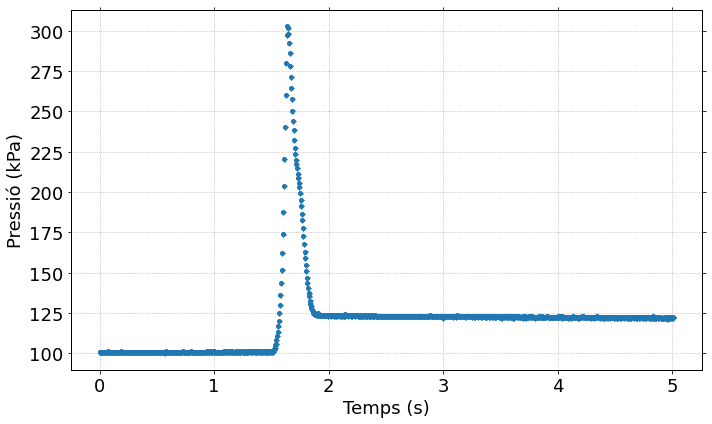

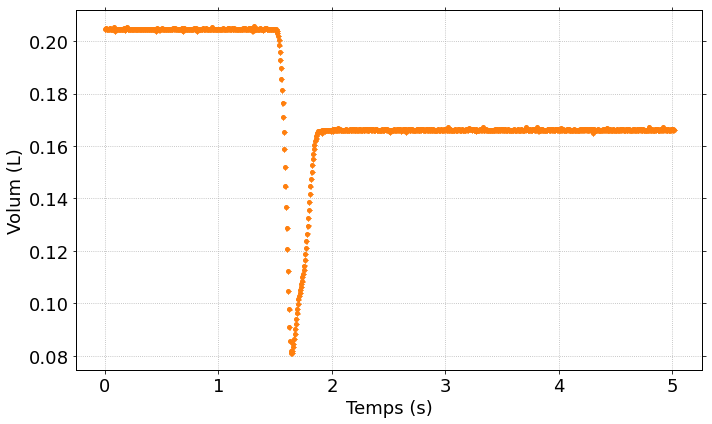

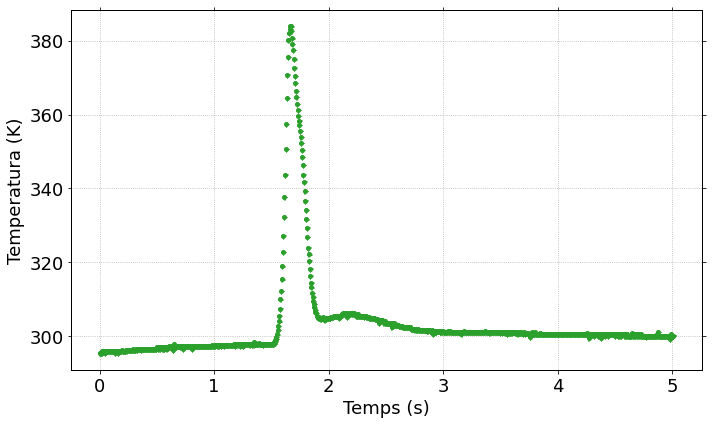

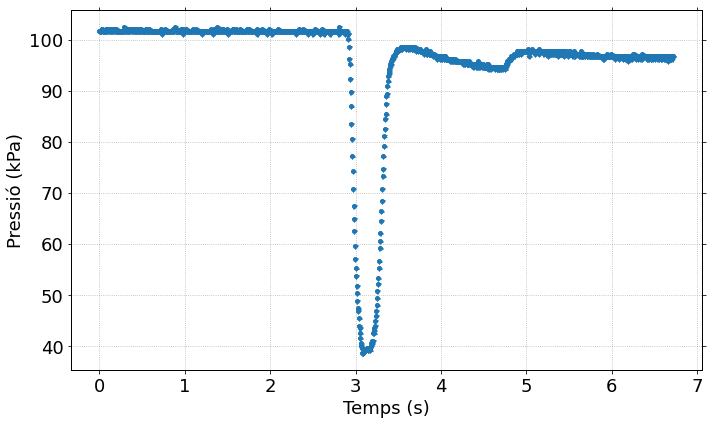

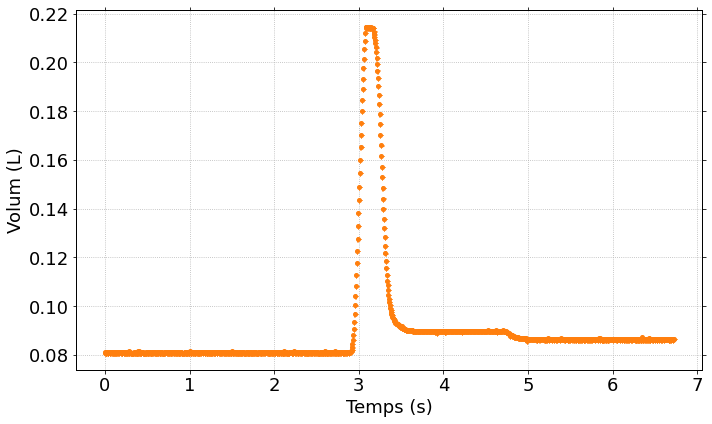

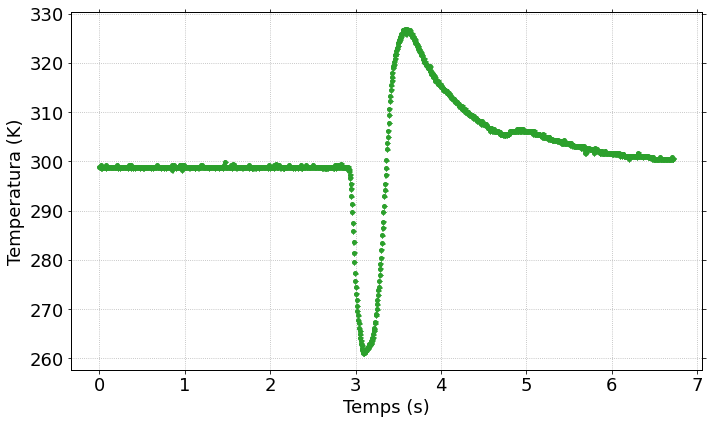

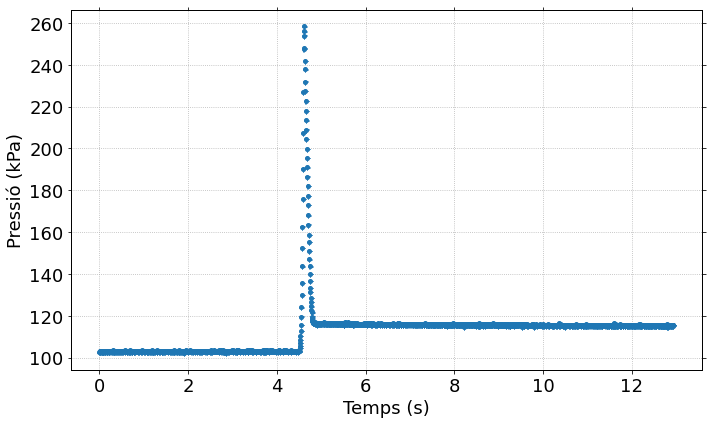

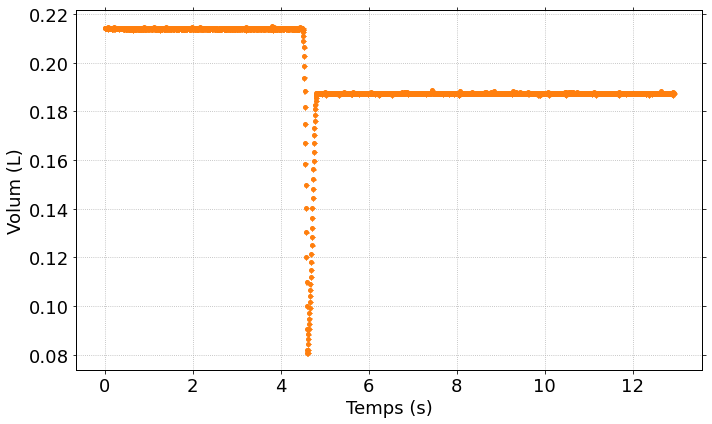

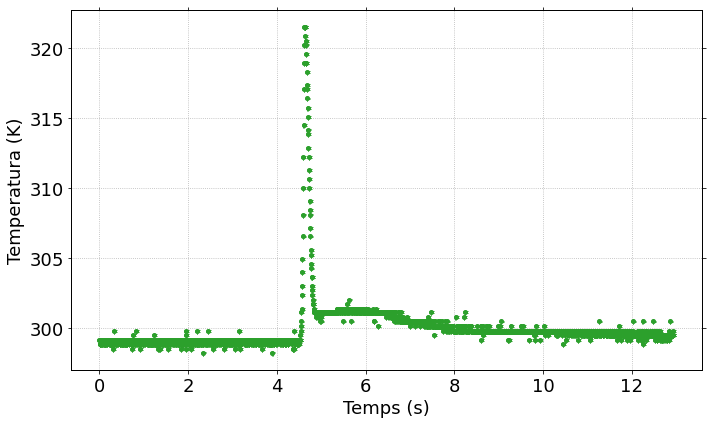

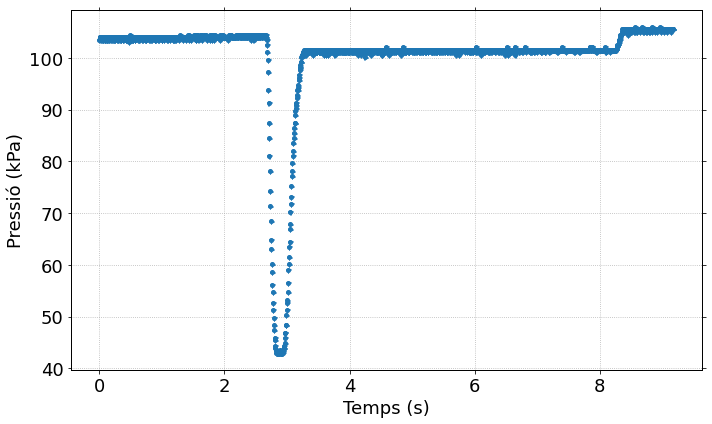

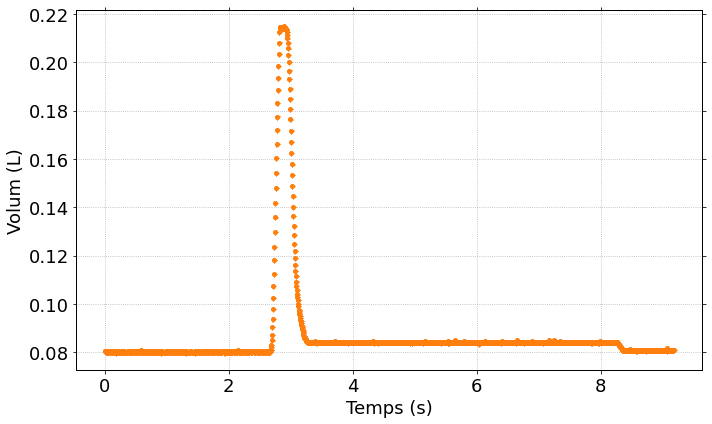

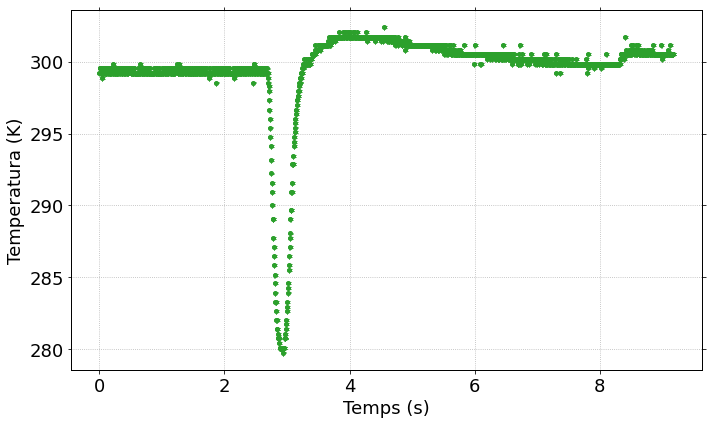

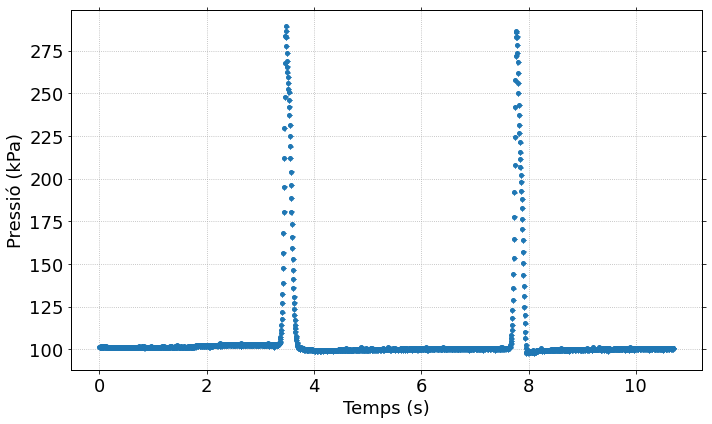

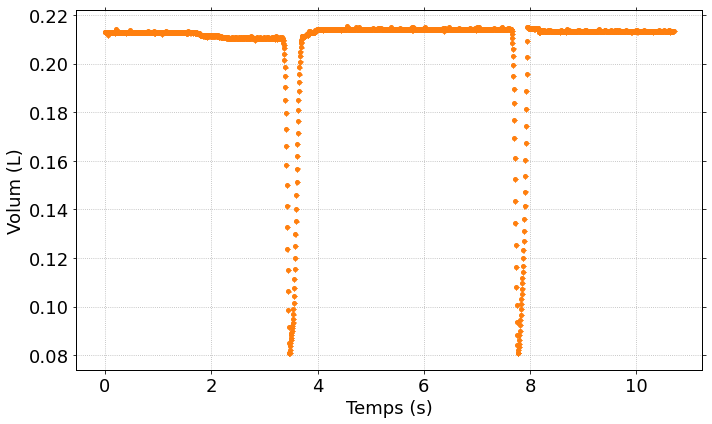

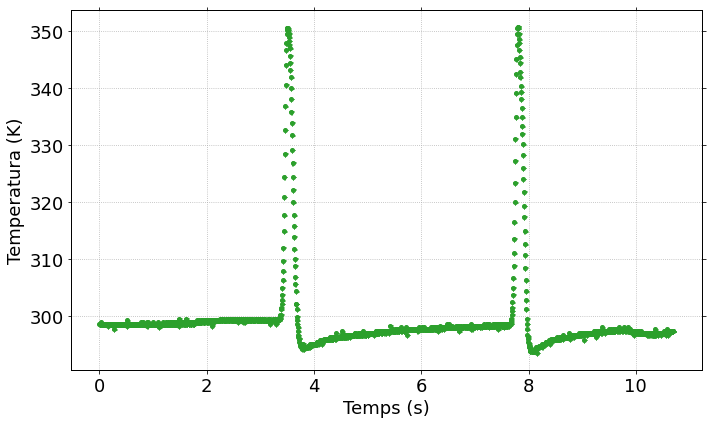

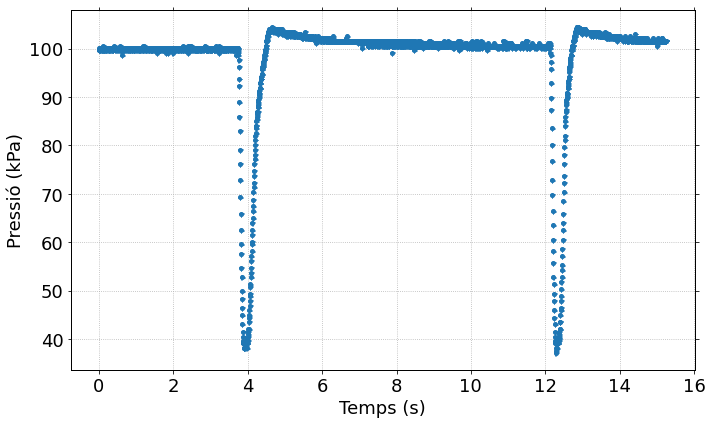

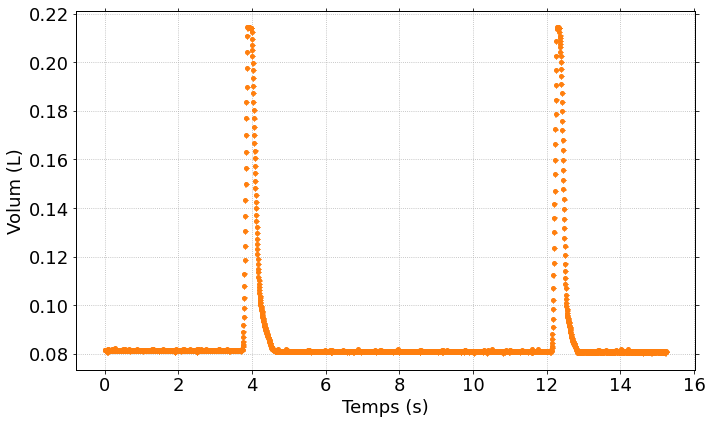

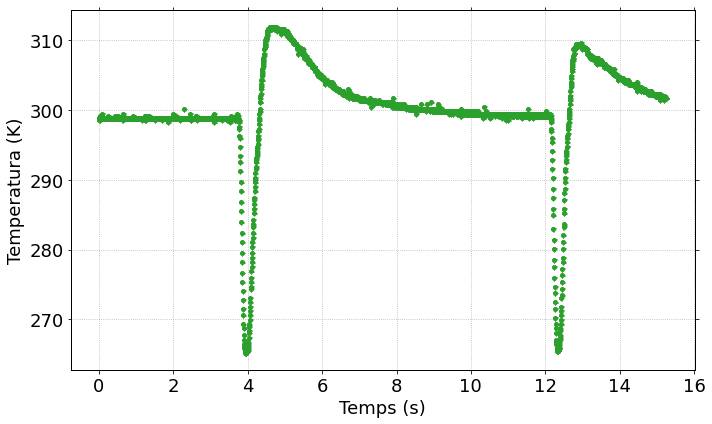

In [10]:
# === 3×1 panels per run using your existing graph_display ===
# Builds time–P, time–V, time–T plots (saved as PNGs by graph_display),
# then stitches them into a single 3-plot figure per run.
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def _get_time_measure(run_dict, idx):
    """Return the time Measure at index idx (handles Vector_Measure in t_list)."""
    t_source = run_dict["t_list"]  # first element holds the Vector_Measure you created
    if isinstance(t_source, Vector_Measure):
        return t_source.measure_vector[idx]
    # Else t_list already contains Measures per index:
    return run_dict["t_list"][idx]

for key, run in runs.items():
    P_list  = run["P_list"]
    V_list  = run["V_L_list"]
    T_list  = run["T_K_list"]
    n       = min(len(P_list), len(V_list), len(T_list))

    # Build datasets of (time_i, value_i)
    data_tP = [(_get_time_measure(run, i), P_list[i]) for i in range(n)]
    data_tV = [(_get_time_measure(run, i), V_list[i]) for i in range(n)]
    data_tT = [(_get_time_measure(run, i), T_list[i]) for i in range(n)]

    # Filenames for the three single plots
    fP = f"{key}_time_vs_P"
    fV = f"{key}_time_vs_V"
    fT = f"{key}_time_vs_T"

    # 1) time vs Pressure (kPa)
    graph_display([data_tP],
        r"Temps", "s",
        r"Pressió", "kPa",
        "", f"{key}: Temps vs Pressió",
        labels=[r"Dades"],
        llista_teos=["o"],
        colors=["tab:blue"],
        grid=True, fouraxis=True
    )[0].savefig(fP + ".png", dpi=300, bbox_inches="tight")

    # 2) time vs Volume (L)
    graph_display([data_tV],
        r"Temps", "s",
        r"Volum", "L",
        "", f"{key}: Temps vs Volum",
        labels=[r"Dades"],
        llista_teos=["o"],
        colors=["tab:orange"],
        grid=True, fouraxis=True
    )[0].savefig(fV + ".png", dpi=300, bbox_inches="tight")

    # 3) time vs Temperature (K)
    graph_display([data_tT],
        r"Temps", "s",
        r"Temperatura", "K",
        "", f"{key}: Temps vs Temperatura",
        labels=[r"Dades"],
        llista_teos=["o"],
        colors=["tab:green"],
        grid=True, fouraxis=True
    )[0].savefig(fT + ".png", dpi=300, bbox_inches="tight")


    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1], wspace=0.06, hspace=0.10)

    ax_top_left  = fig.add_subplot(gs[0, 0])
    ax_top_right = fig.add_subplot(gs[0, 1])
    ax_bottom    = fig.add_subplot(gs[1, :])   # spans both columns

    for ax, fname, ttl in [
        (ax_top_right,  fP + ".png", f"{key}: Temps vs P"),
        (ax_top_left, fV + ".png", f"{key}: Temps vs V"),
        (ax_bottom,    fT + ".png", f"{key}: Temps vs T"),
    ]:
        img = mpimg.imread(fname)
        ax.imshow(img)
        ax.set_title(ttl)
        ax.axis("off")
    
    IMDIR = "p2_images"
    os.makedirs(IMDIR, exist_ok=True)
    out_path = os.path.join(IMDIR, f"{key}_time_PVT_panel_2x1.png")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

print("Figures saved succesfully.")

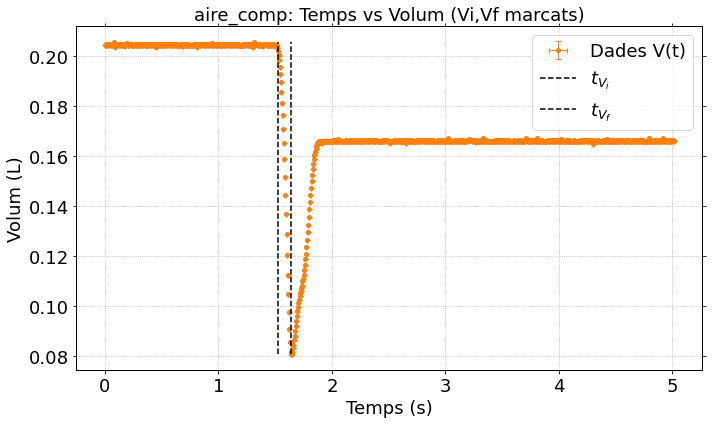

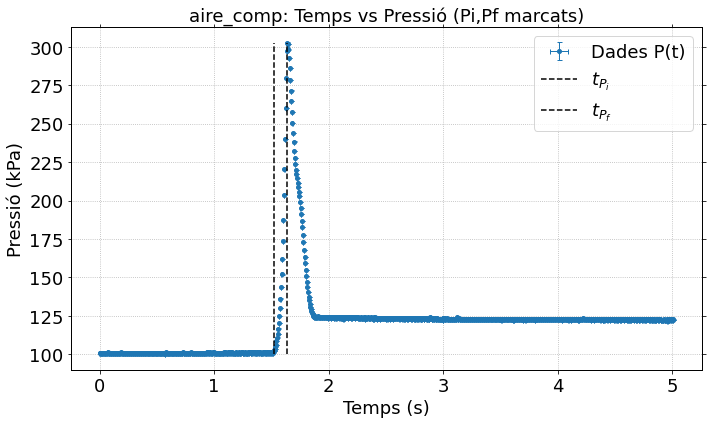

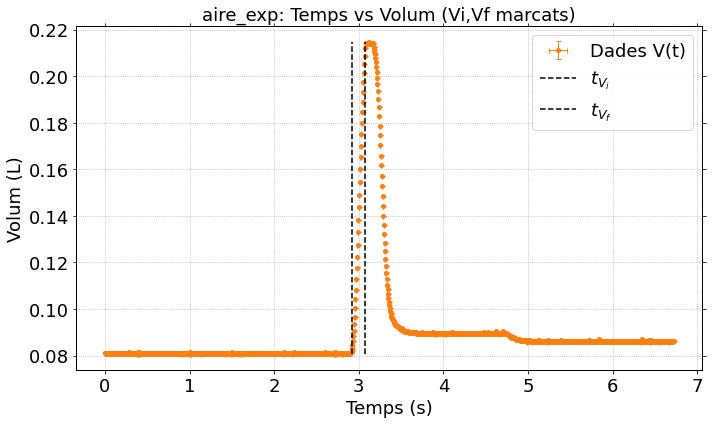

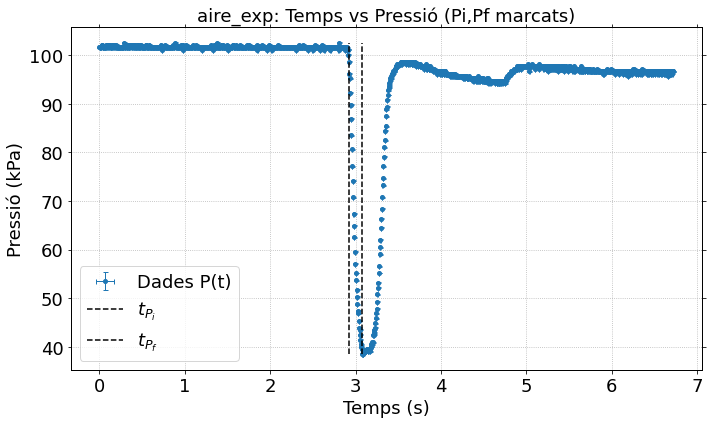

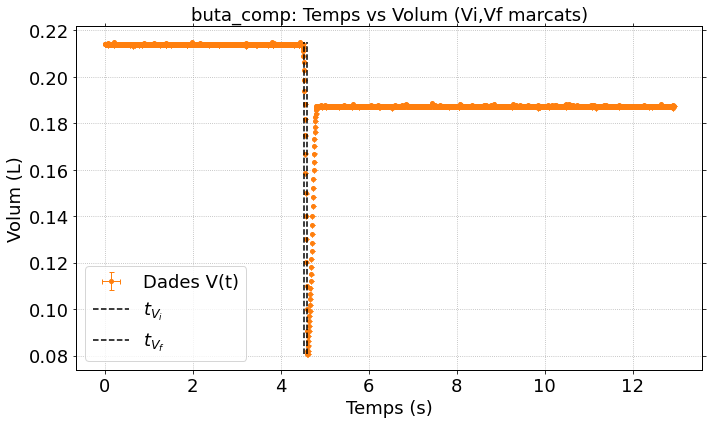

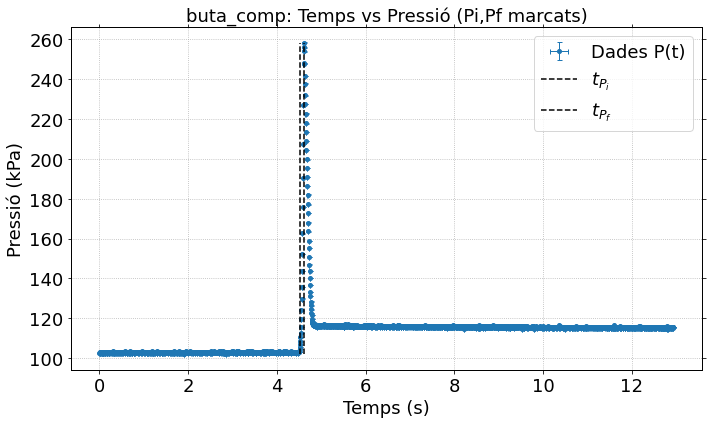

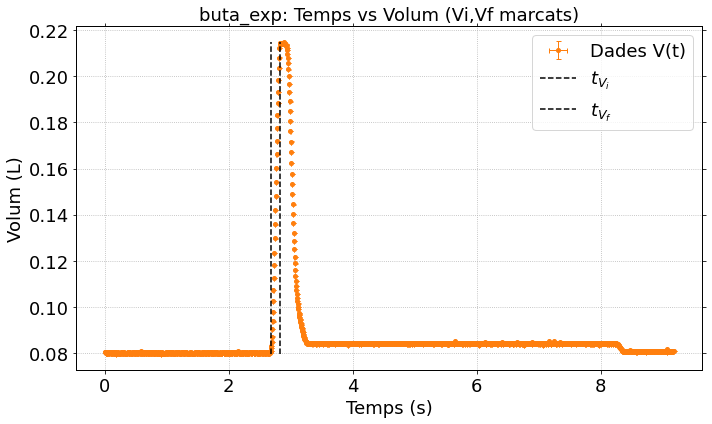

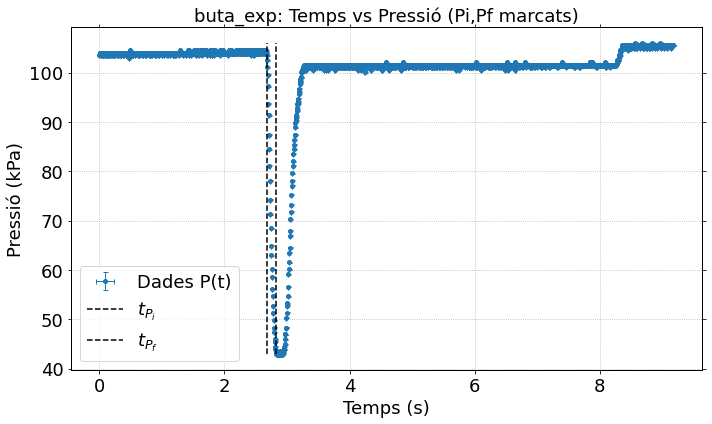

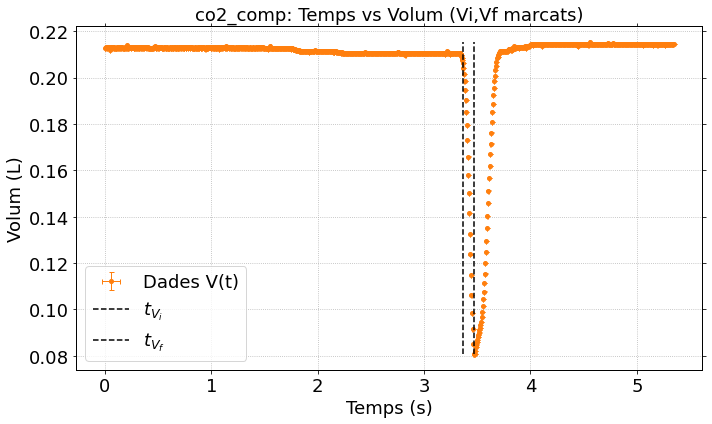

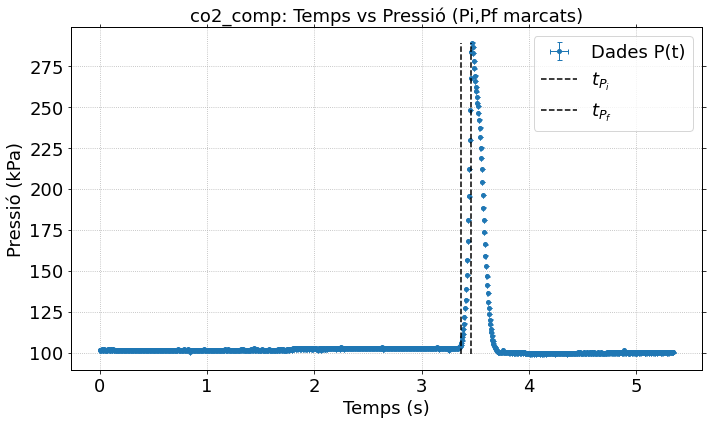

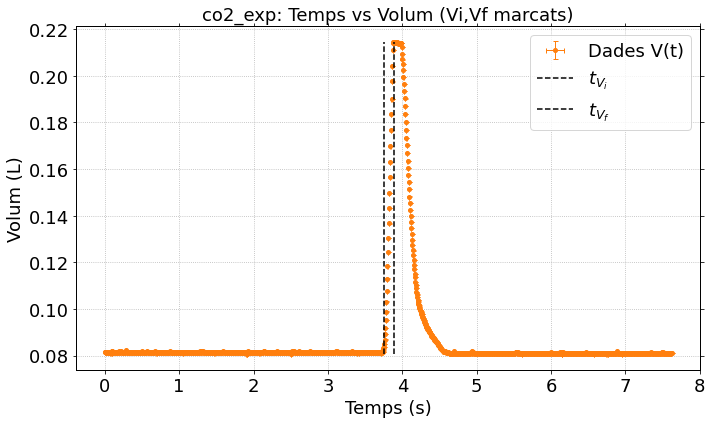

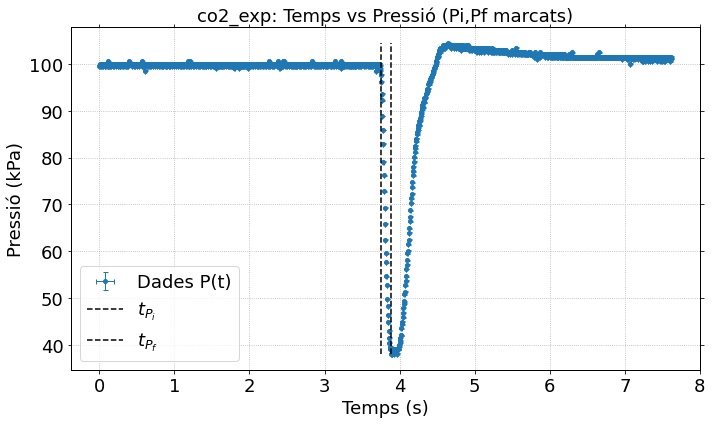

In [18]:
import numpy as np

def make_event(i_idx, f_idx):
    """Bundle times and state at initial/final indices into a dict of Measures."""
    return {
        "idx_i": i_idx,
        "idx_f": f_idx,
        "t_i":   t_all[i_idx],
        "t_f":   t_all[f_idx],
        "P_i":   P_all[i_idx],
        "P_f":   P_all[f_idx],
        "V_i":   V_all[i_idx],
        "V_f":   V_all[f_idx],
        "T_i":   T_all[i_idx],
        "T_f":   T_all[f_idx],
    }

# --- helpers ---
def _maybe_half_series(vals, key):
    """If key mentions CO2, keep first half; otherwise full series."""
    if "co2" in key.lower():
        n = len(vals)
        return vals[:max(1, n//2)]
    return vals

def _series_arrays(t_list, y_list):
    """Return time, value, and uncertainties as numpy arrays from Measure lists."""
    t = np.array([ti.magnitude if isinstance(ti, Measure) else ti for ti in t_list], dtype=float)
    y = np.array([yi.magnitude for yi in y_list], dtype=float)
    return t, y

# --- helpers for the new rule ---
def avg_discrete_diff(y):
    import numpy as np
    if len(y) < 2: return 0.0
    return float(np.average(np.abs(np.diff(y))))

def pick_initial_max_timegap(t, y, idx_f, min_jump):
    """
    Pick the initial index i (≤ idx_f) that MAXIMIZES |t_f - t_i|
    subject to |y_f - y_i| > min_jump. If none, return 0.
    """
    tf, yf = t[idx_f], y[idx_f]
    best_i, best_dt = 0, -1.0
    for i in range(0, idx_f-1):  # earlier (and possibly i=0) only
        if abs(y[i+1] - y[i]) > min_jump:
            dt = abs(tf - t[i])
            if dt > best_dt:
                best_i, best_dt = i, dt
    return best_i


def _pick_initial_from_extreme(t, y, idx_extreme, threshold):
    """
    Walk backwards from the extreme index until |y_ext - y[i]| > threshold.
    If not found, fall back to the start index 0.
    """
    y_ext = y[idx_extreme]
    for i in range(idx_extreme-1, -1, -1):
        if abs(y_ext - y[i]) < threshold:
            return i
    return 0

def _vline_dataset(x_const, y_min, y_max, n=200):
    ys = np.linspace(y_min, y_max, n)
    return [(x_const, float(y)) for y in ys]

# --- main loop over runs ---
for key, run in runs.items():
    if "exp" in key:
        
        mode = "expansion"  # default to expansion; edit as needed
    else:
        mode = "compression"
    # (Optionally) split CO2 data in half
    t_all = _maybe_half_series(run["t_list"], key)
    V_all = _maybe_half_series(run["V_L_list"], key)
    P_all = _maybe_half_series(run["P_list"],   key)
    T_all = _maybe_half_series(run["T_K_list"], key)
    
    # arrays for calc
    tV, V = _series_arrays(t_all, V_all)
    tP, P = _series_arrays(t_all, P_all)  # same time base assumed

    # FINAL picks by mode
    if mode == "expansion":
        idx_Vf = int(np.argmax(V))
        idx_Pf = int(np.argmin(P))
    else:  # compression
        idx_Vf = int(np.argmin(V))
        idx_Pf = int(np.argmax(P))

    # FINALs already picked: idx_Vf, idx_Pf
    avgdV = avg_discrete_diff(V)
    avgdP = avg_discrete_diff(P)

    # NEW initial picks: nearest in time to final, with |Δy| > avg(|Δy|)
    idx_Vi = pick_initial_max_timegap(tV, V, idx_Vf, avgdV*5)
    idx_Pi = pick_initial_max_timegap(tP, P, idx_Pf, avgdP*5)

    
        # Map guideline → pick indices
    k = key.lower()
    if   "aire_comp" in k:  # tV_i, tV_f
        event = make_event(idx_Vi, idx_Vf)
    elif "aire_exp"  in k:  # tV_i, tP_f
        event = make_event(idx_Vi, idx_Pf)
    elif "buta_comp" in k:  # tP_i, tP_f
        event = make_event(idx_Pi, idx_Pf)
    elif "buta_exp"  in k:  # tP_i, tP_f
        event = make_event(idx_Pi, idx_Pf)
    elif "co2_comp"  in k:  # tV_i, tV_f
        event = make_event(idx_Vi, idx_Vf)
    elif "co2_exp"   in k:  # tP_i, tP_f
        event = make_event(idx_Pi, idx_Pf)
    else:
        # fallback: use volume-based indices
        event = make_event(idx_Vi, idx_Vf)

    # Save in runs dict for later use
    runs[key]["event"] = event
    
    
    
    # --- Use official event times for vlines ---
    t_i = event["t_i"];  t_f = event["t_f"]
    x_ti = t_i.magnitude if isinstance(t_i, Measure) else float(t_i)
    x_tf = t_f.magnitude if isinstance(t_f, Measure) else float(t_f)

    # Build datasets for graph_display (time on x)
    data_tV = list(zip(t_all, V_all))
    data_tP = list(zip(t_all, P_all))

    # Vertical lines at chosen times (same x for V and P figures)
    yVmin, yVmax = float(np.min(V)), float(np.max(V))
    yPmin, yPmax = float(np.min(P)), float(np.max(P))
    vline_Vi = _vline_dataset(x_ti, yVmin, yVmax)
    vline_Vf = _vline_dataset(x_tf, yVmin, yVmax)
    vline_Pi = _vline_dataset(x_ti, yPmin, yPmax)
    vline_Pf = _vline_dataset(x_tf, yPmin, yPmax)

    # --- Plot time vs V with vertical black lines at Vi, Vf ---
    graph_display(
        [data_tV, vline_Vi, vline_Vf],
        r"Temps", "s",
        r"Volum", V_all[0].unitats if isinstance(V_all[0], Measure) else "",
         rf"{key}: Temps vs Volum (Vi,Vf marcats)",
        labels=[r"Dades V(t)", r"$t_{V_i}$", r"$t_{V_f}$"],
        llista_teos=["o", "--", "--"],
        colors=["tab:orange", "black", "black"],
        grid=True, fouraxis=True,
        filename=f"{key}_time_vs_V_with_marks"
    )

    # --- Plot time vs P with vertical black lines at Pi, Pf ---
    graph_display(
        [data_tP, vline_Pi, vline_Pf],
        r"Temps", "s",
        r"Pressió", P_all[0].unitats if isinstance(P_all[0], Measure) else "",
        rf"{key}: Temps vs Pressió (Pi,Pf marcats)",
        labels=[r"Dades P(t)", r"$t_{P_i}$", r"$t_{P_f}$"],
        llista_teos=["o", "--", "--"],
        colors=["tab:blue", "black", "black"],
        grid=True, fouraxis=True,
        filename=f"{key}_time_vs_P_with_marks"
    )
    

    
    
    
    


In [16]:
print(PV_quads)

[[('Pressio_kpa_aire_comp_pt311: (113.300000000000 +/- 0.100000000000000) kPa', 'Volum_l_aire_comp_pt305: (0.202031200000000 +/- 0.0000312000000000000) L'), ('Pressio_kpa_aire_comp_pt328: (302.700000000000 +/- 0.100000000000000) kPa', 'Volum_l_aire_comp_pt328: (0.0809128000000000 +/- 0.0000312000000000000) L')], [('Pressio_kpa_aire_exp_pt560: (101.100000000000 +/- 0.100000000000000) kPa', 'Volum_l_aire_exp_pt585: (0.0844072000000000 +/- 0.0000312000000000000) L'), ('Pressio_kpa_aire_exp_pt615: (38.6000000000000 +/- 0.100000000000000) kPa', 'Volum_l_aire_exp_pt625: (0.214667200000000 +/- 0.0000312000000000000) L')], [('Pressio_kpa_buta_comp_pt905: (108.400000000000 +/- 0.100000000000000) kPa', 'Volum_l_buta_comp_pt642: (0.214667200000000 +/- 0.0000312000000000000) L'), ('Pressio_kpa_buta_comp_pt921: (258.300000000000 +/- 0.100000000000000) kPa', 'Volum_l_buta_comp_pt921: (0.0806008000000000 +/- 0.0000312000000000000) L')], [('Pressio_kpa_buta_exp_pt537: (101.100000000000 +/- 0.100000000

/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)


V0 (aire, finestra [t_i,t_f]) = 'Volum mort (regressió aire): (0.0257254914338873 +/- 0.000756451031381290) L'


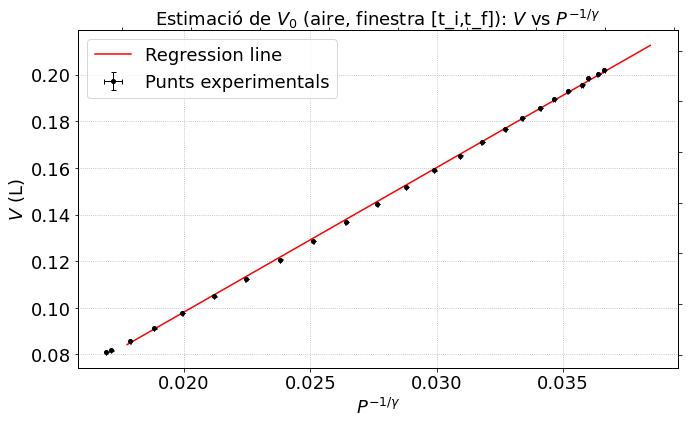

In [21]:
# --- 2) Determine V0 from AIR COMPRESSION using ONLY the event window [t_i, t_f] ---
gamma_air = 1.4
key_air_comp = "aire_comp"   # adjust if your key differs

P_air = runs[key_air_comp]["P_list"]
V_air = runs[key_air_comp]["V_L_list"]

# Use official indices from the detected event
i0 = runs[key_air_comp]["event"]["idx_i"]
i1 = runs[key_air_comp]["event"]["idx_f"]
idx_range = range(min(i0, i1), max(i0, i1) + 1)

# Build x = P^(-1/gamma), y = V only within [t_i, t_f]
x_list = [inv_pressure_power(P_air[i], f"{key_air_comp}_i{i}") for i in idx_range]
y_list = [V_air[i] for i in idx_range]
data_V_vs_Pminv = list(zip(x_list, y_list))

# Linear regression on the event window:  V = a + b * P^(-1/gamma)  =>  V0 = -a
a_V0, b_V0, r_V0, _, _ = regresio(
    data_V_vs_Pminv,
    r"$P^{-1/\gamma}$", "",
    r"$V$", "L",
    r"Estimació de $V_0$ (aire, finestra [t_i,t_f]): $V$ vs $P^{-1/\gamma}$",
    "display", fouraxis=True, grid=True
)
V0_reg = formulador(-a_V0.var, [a_V0], "Volum mort (regressió aire)", "V0_reg", "L")
print("V0 (aire, finestra [t_i,t_f]) =", V0_reg)

# --- 3) Rebuild V_eff for ALL runs using this V0 ---
for key, d in runs.items():
    d["V_eff_list"] = [add_dead_volume(d["V_L_list"][i], V0_reg, f"{key}_i{i}") for i in range(len(d["V_L_list"]))]


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)


[aire_comp] — model checks in window [t_i,t_f]
  Isothermal:    P vs 1/V   → r = 'Coe: (0.995790907740864 +/- 0.100000000000000)  '
  Adiabatic ln:  lnP vs lnV → slope b = 'B: (-1.4080551656715732 +/- 0.006853490560160535)  units '   (expect ≈ -1.40000000000000 )  r = 'Coe: (0.9994790684253868 +/- 0.100000000000000)  '
  Adiabatic lin: V vs P^{-1/γ} → r = 'Coe: (0.9996062182069622 +/- 0.100000000000000)  '   (intercept ~ -V0 if V is experimental)


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)


[aire_exp] — model checks in window [t_i,t_f]
  Isothermal:    P vs 1/V   → r = 'Coe: (0.9942764028105253 +/- 0.100000000000000)  '
  Adiabatic ln:  lnP vs lnV → slope b = 'B: (-1.1757006369880074 +/- 0.012728522891649701)  units '   (expect ≈ -1.40000000000000 )  r = 'Coe: (0.9966124414415556 +/- 0.100000000000000)  '
  Adiabatic lin: V vs P^{-1/γ} → r = 'Coe: (0.9948267876646553 +/- 0.100000000000000)  '   (intercept ~ -V0 if V is experimental)


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)


...

[co2_exp] — model checks in window [t_i,t_f]
  Isothermal:    P vs 1/V   → r = 'Coe: (0.9978356872146287 +/- 0.100000000000000)  '
  Adiabatic ln:  lnP vs lnV → slope b = 'B: (-1.1745459029241114 +/- 0.008547174425445263)  units '   (expect ≈ -1.30000000000000 )  r = 'Coe: (0.998677880883081 +/- 0.100000000000000)  '
  Adiabatic lin: V vs P^{-1/γ} → r = 'Coe: (0.9975214035783031 +/- 0.100000000000000)  '   (intercept ~ -V0 if V is experimental)


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)


[buta_comp] — model checks in window [t_i,t_f]
  Isothermal:    P vs 1/V   → r = 'Coe: (0.9978692301861889 +/- 0.100000000000000)  '
  Adiabatic ln:  lnP vs lnV → slope b = 'B: (-1.1114049852356593 +/- 0.008563130750624074)  units '   (expect ≈ -1.09000000000000 )  r = 'Coe: (0.9991103377125655 +/- 0.100000000000000)  '
  Adiabatic lin: V vs P^{-1/γ} → r = 'Coe: (0.999439749439174 +/- 0.100000000000000)  '   (intercept ~ -V0 if V is experimental)


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)


[buta_exp] — model checks in window [t_i,t_f]
  Isothermal:    P vs 1/V   → r = 'Coe: (0.9994158772029064 +/- 0.100000000000000)  '
  Adiabatic ln:  lnP vs lnV → slope b = 'B: (-1.0774799270500872 +/- 0.004220357816645416)  units '   (expect ≈ -1.09000000000000 )  r = 'Coe: (0.999601268710464 +/- 0.100000000000000)  '
  Adiabatic lin: V vs P^{-1/γ} → r = 'Coe: (0.9994543103861973 +/- 0.100000000000000)  '   (intercept ~ -V0 if V is experimental)


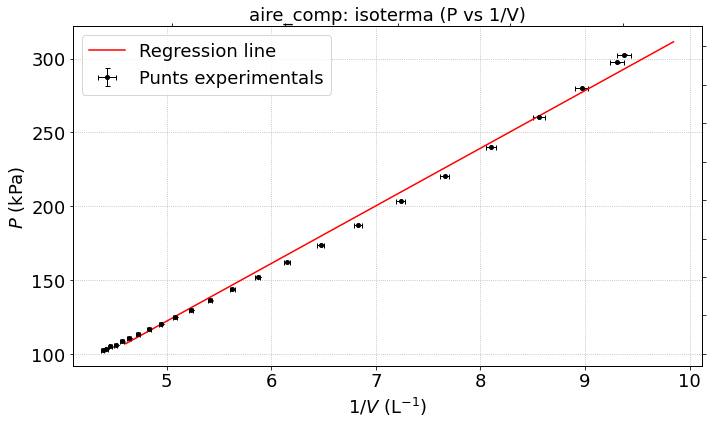

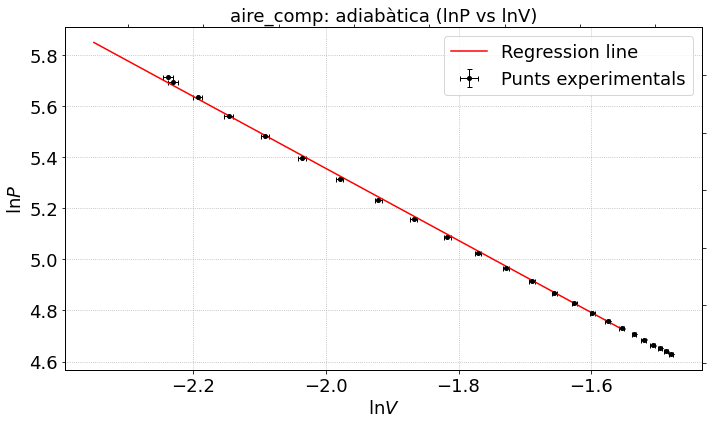

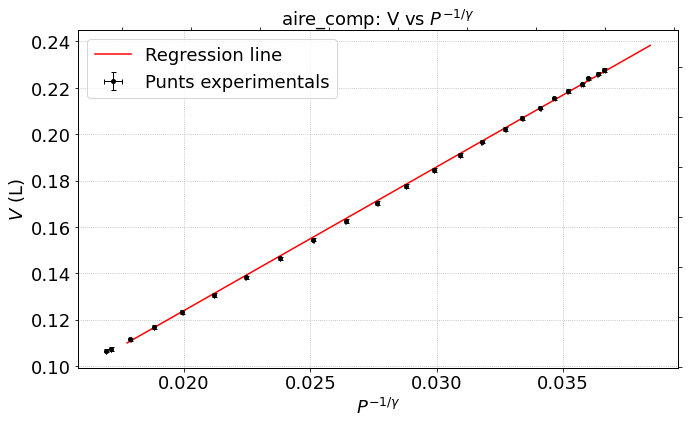

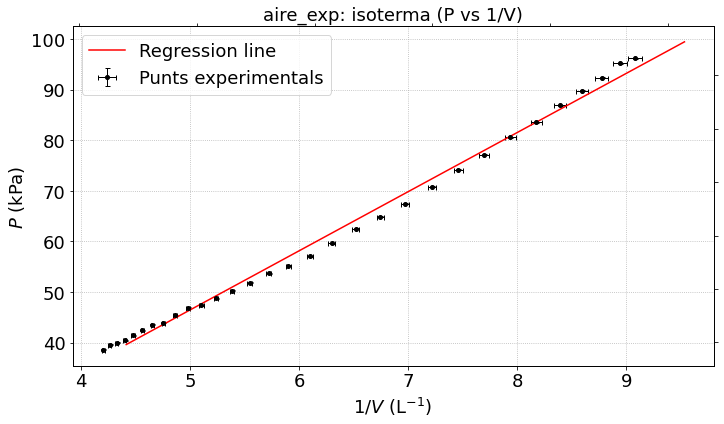

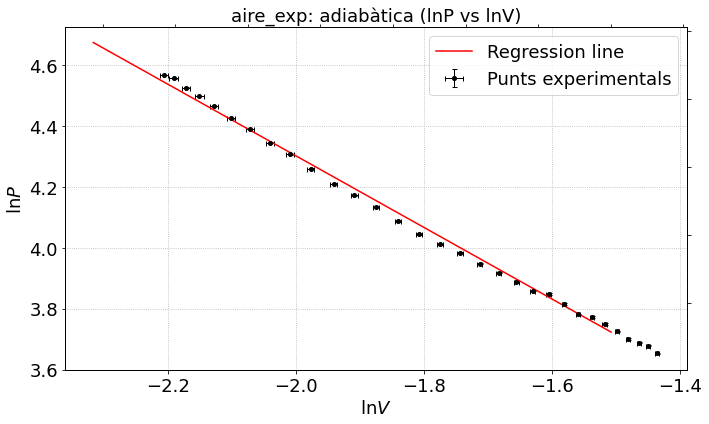

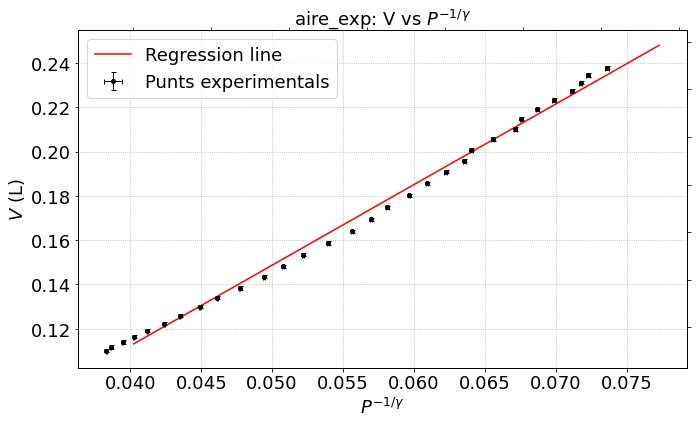

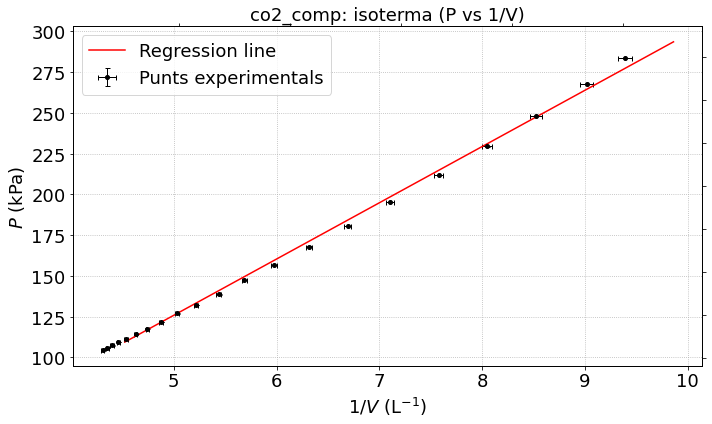

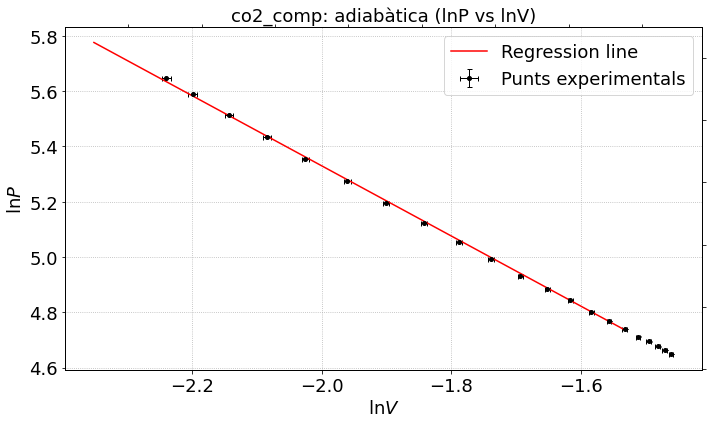

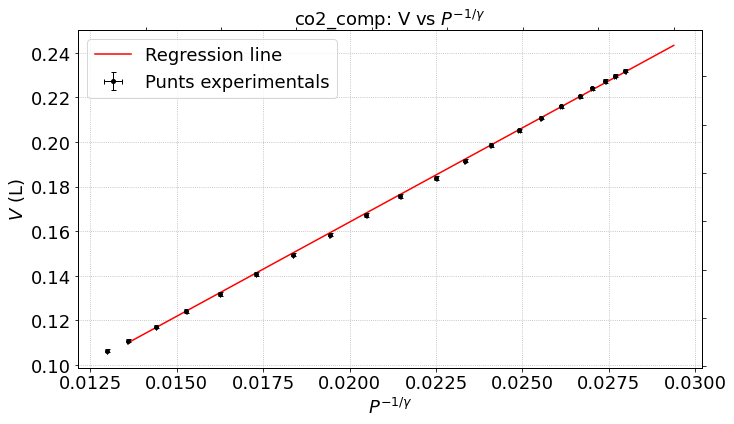

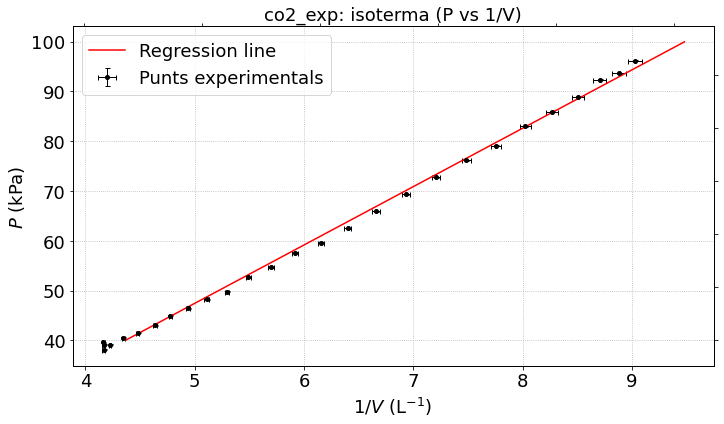

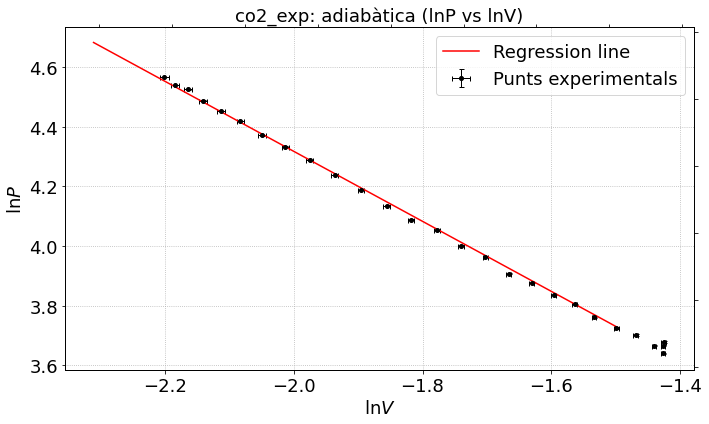

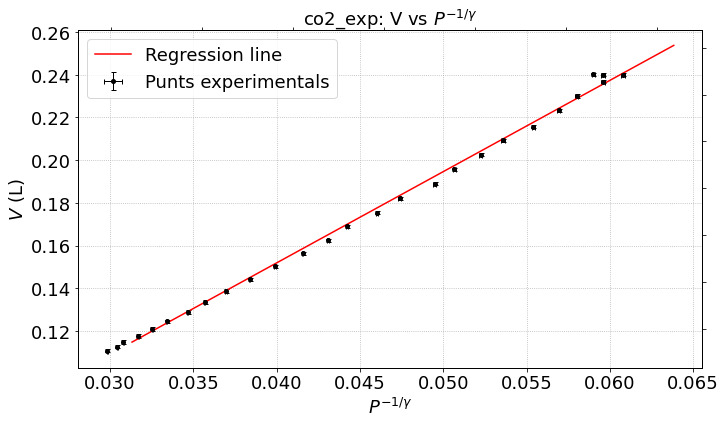

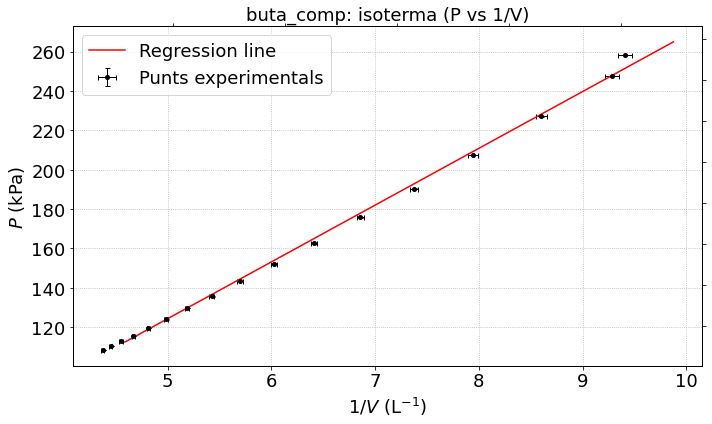

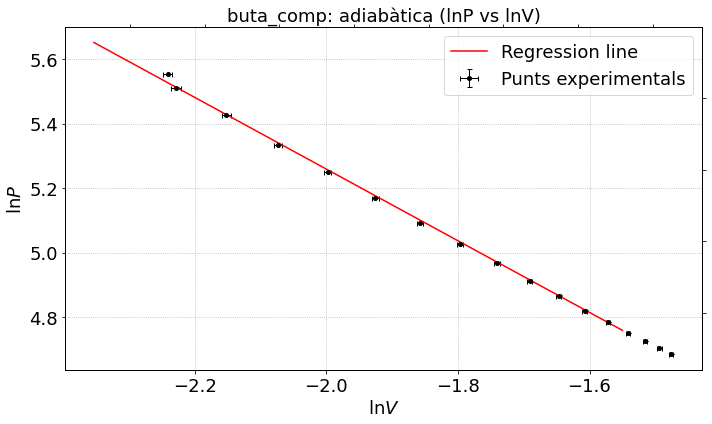

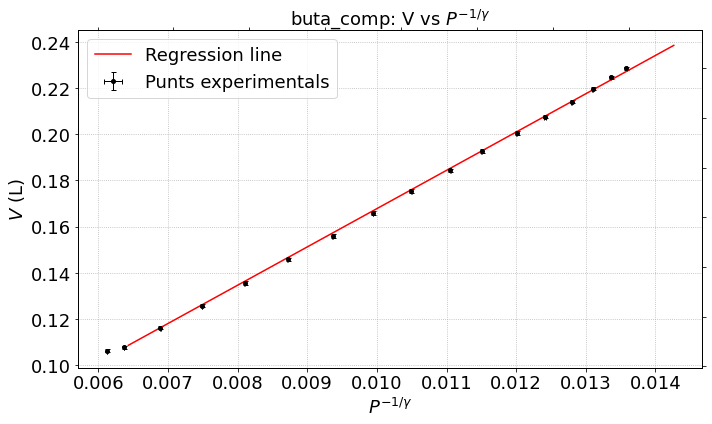

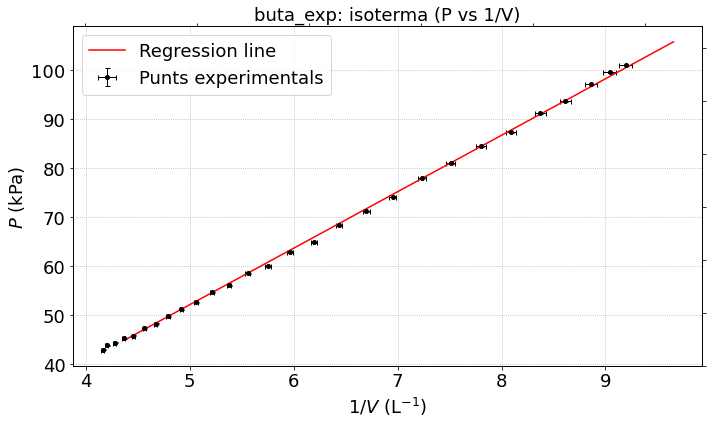

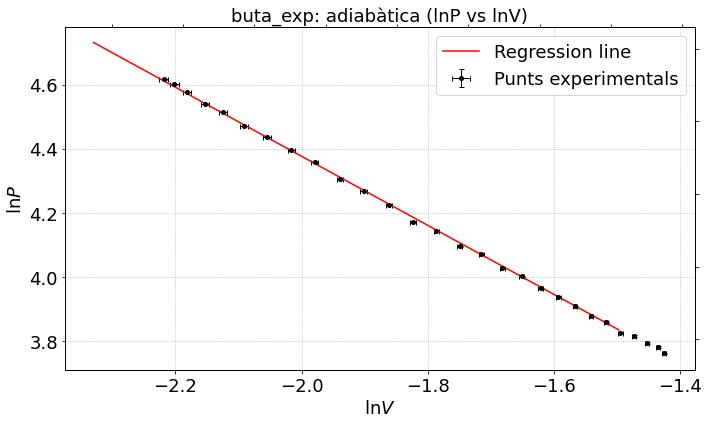

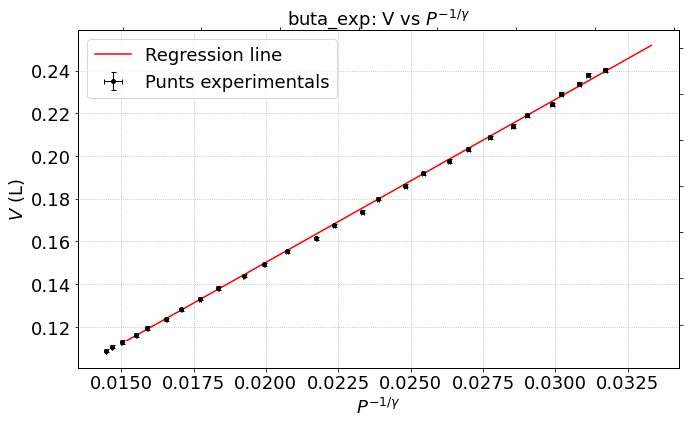

In [24]:
def verify_eos_for_run(key, gamma_guess=1.4):
    d = runs[key]
    i0, i1 = d["event"]["idx_i"], d["event"]["idx_f"]
    idxs = range(min(i0,i1), max(i0,i1)+1)

    P = [d["P_list"][i] for i in idxs]
    V = [d["V_eff_list"][i] for i in idxs]  # prefer V_eff if you built it

    # 1) Isothermal: P vs 1/V  (expect linear; PV≈const)
    invV = [formulador(1.0/Vi.var, [Vi], "1/V", "invV_"+Vi.var_name, "1/L") for Vi in V]
    data_iso = list(zip(invV, P))
    a_iso, b_iso, r_iso, _, _ = regresio(data_iso, r"$1/V$", r"L$^{-1}$", r"$P$", "kPa",
                                         rf"{key}: isoterma (P vs 1/V)", "display", grid=True, fouraxis=True)

    # 2) Adiabatic (with gamma_guess): lnP vs lnV  (expect slope ≈ -γ)
    ln_pairs = [(formulador(log(Vi.var), [Vi], "lnV", "lnV_"+Vi.var_name, "logL"),
                 formulador(log(Pi.var), [Pi], "lnP", "lnP_"+Pi.var_name, "logkPa")) for Vi,Pi in zip(V,P)]
    a_ad, b_ad, r_ad, _, _ = regresio(ln_pairs, r"$\ln V$", "", r"$\ln P$", "",
                                      rf"{key}: adiabàtica (lnP vs lnV)", "display", grid=True, fouraxis=True)

    # 3) Adiabatic (linearized alt): V vs P^{-1/γ}  (expect linear; intercept = -V0 if using V_exp)
    x_ag = [formulador(Pi.var**(-1.0/gamma_guess), [Pi], "P^{-1/g}", "Pinvg_"+Pi.var_name, "") for Pi in P]
    data_ag = list(zip(x_ag, V))
    a_ag, b_ag, r_ag, _, _ = regresio(data_ag, r"$P^{-1/\gamma}$", "", r"$V$", V[0].unitats,
                                      rf"{key}: V vs $P^{{-1/\gamma}}$", "display", grid=True, fouraxis=True)

    # Report
    print(f"[{key}] — model checks in window [t_i,t_f]")
    print("  Isothermal:    P vs 1/V   → r =", r_iso)
    print("  Adiabatic ln:  lnP vs lnV → slope b =", b_ad, "  (expect ≈", -gamma_guess, ")  r =", r_ad)
    print("  Adiabatic lin: V vs P^{-1/γ} → r =", r_ag, "  (intercept ~ -V0 if V is experimental)")

# Run EOS checks for all gases/modes with typical γ values (edit if needed)
gamma_map = {
    "aire": 1.40,   # air
    "co2":  1.30,   # CO₂ (≈1.30 at ~300 K)
    "buta": 1.09,   # butane (≈1.09–1.10)
}

for gas in ["aire", "co2", "buta"]:
    for mode in ["comp", "exp"]:
        key = f"{gas}_{mode}"
        if key in runs:
            verify_eos_for_run(key, gamma_guess=gamma_map[gas])